In [32]:
"""
SAM-Med3D Orthogonal Visualization

Shows same slice number across all 3 anatomical views (Axial, Coronal, Sagittal)
"""

'\nSAM-Med3D Orthogonal Visualization\n\nShows same slice number across all 3 anatomical views (Axial, Coronal, Sagittal)\n'

In [33]:
# Bootstrap required packages (idempotent)
import sys, subprocess, importlib.util

def _ensure_pkg(pip_name, import_name=None):
    name = import_name or pip_name
    if importlib.util.find_spec(name) is None:
        print(f"Installing {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])
    else:
        print(f"OK: {name}")

_ensure_pkg("numpy")
_ensure_pkg("matplotlib")
_ensure_pkg("SimpleITK", "SimpleITK")
_ensure_pkg("torchio")
_ensure_pkg("pyyaml", "yaml")
# Torch is large; just warn if missing
try:
    import torch  # noqa: F401
    print("OK: torch")
except Exception:
    print("WARN: torch not found. Install a suitable CPU/GPU build manually if needed.")

OK: numpy
OK: matplotlib
OK: SimpleITK
OK: torchio
OK: yaml
OK: torch


In [34]:
import sys
from pathlib import Path
import numpy as np
import torch
import SimpleITK as sitk
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
import random
import yaml
import torch.nn.functional as F

In [35]:
import json
import inspect
from pathlib import Path

# Self-patch: ensure plot_orthogonal_views enforces Z=Y=X with crosshairs
nb_path = Path('SAM_Visualization_ORTHOGONAL_FINAL.ipynb')


def plot_orthogonal_views(
    image_vol,
    seg_vol,
    gt_mask_vol=None,
    title="",
    n_slices=3,
    modality="CT",
    points=None,
    show_crosshair=False,
    crosshair_color='y',
):
    """
    Orthogonal views with SAME index along all axes per point.
    For each n we plot the three planes that intersect at (s_n, s_n, s_n):
      - AXIAL at X=s_n (transverse body cross-section)
      - CORONAL at Y=s_n (front-to-back view)
      - SAGITTAL at Z=s_n (side view)

    Args:
        image_vol: numpy array with image intensities (D, H, W)
        seg_vol: numpy array segmentation (D, H, W)
        gt_mask_vol: optional ground-truth mask (D, H, W)
        title: figure title
        n_slices: number of orthogonal points to render
        modality: string label (CT/MR)
        points: iterable of indices overriding automatic selection
        show_crosshair: if True, draw crosshair lines at the slice location
        crosshair_color: matplotlib color used for crosshair lines
    """
    D, H, W = image_vol.shape
    print("\n" + "=" * 70)
    print(f"📊 Orthogonal Views: {title}")
    print(f"Volume shape: (D={D}, H={H}, W={W})")

    # Display window from foreground only
    fg_mask = image_vol > (image_vol.min() + 0.05 * (image_vol.max() - image_vol.min()))
    if fg_mask.sum() > 100:
        fg = image_vol[fg_mask]
        if "MR" in modality.upper():
            vmin, vmax = np.percentile(fg, [1, 99])
        else:
            mu, sd = fg.mean(), fg.std()
            vmin, vmax = max(mu - 2 * sd, fg.min()), min(mu + 2 * sd, fg.max())
    else:
        vmin, vmax = image_vol.min(), image_vol.max()
    print(f"Display window: [{vmin:.2f}, {vmax:.2f}]")

    # Select indices s so that Z=Y=X=s for each point
    sel = []
    if points is not None and len(points) > 0:
        # Interpret each provided value as s and force (s,s,s)
        ss = []
        for p in points[:n_slices]:
            if isinstance(p, (list, tuple)) and len(p) >= 1:
                s = int(p[0])
            else:
                s = int(p)
            ss.append(s)
        sel = [(int(np.clip(s, 0, min(D, H, W) - 1)),) * 3 for s in ss]
    elif gt_mask_vol is not None and gt_mask_vol.sum() > 0:
        coords = np.argwhere(gt_mask_vol > 0)
        z_min, y_min, x_min = coords.min(axis=0)
        z_max, y_max, x_max = coords.max(axis=0)
        rng_min = int(max(z_min, y_min, x_min))
        rng_max = int(min(z_max, y_max, x_max))
        if rng_max >= rng_min:
            ss = np.linspace(rng_min, rng_max, n_slices).astype(int)
        else:
            # No overlap across axes; use averaged center
            cz = (z_min + z_max) / 2
            cy = (y_min + y_max) / 2
            cx = (x_min + x_max) / 2
            s0 = int(round((cz + cy + cx) / 3))
            half = max(1, min(D, H, W) // 10)
            ss = np.linspace(max(0, s0 - half), min(min(D, H, W) - 1, s0 + half), n_slices).astype(int)
        sel = [(int(np.clip(s, 0, min(D, H, W) - 1)),) * 3 for s in ss]
    else:
        mid = min(D, H, W) // 2
        half = max(1, min(D, H, W) // 10)
        ss = np.linspace(max(0, mid - half), min(min(D, H, W) - 1, mid + half), n_slices).astype(int)
        sel = [(int(s), int(s), int(s)) for s in ss]

    print('Selected 3D points (Z=Y=X):', sel)

    n_cols = 2 if gt_mask_vol is not None else 1
    fig = plt.figure(figsize=(5 * 2, 4 * len(sel)))

    def _maybe_crosshair(ax_obj, horiz, vert):
        if show_crosshair:
            ax_obj.axhline(horiz, color=crosshair_color, alpha=0.6, lw=0.6)
            ax_obj.axvline(vert, color=crosshair_color, alpha=0.6, lw=0.6)

    for i, (z, y, x) in enumerate(sel):
        # AXIAL (transverse body cross-section) - circular view in abdomen
        # Extract from W dimension (third axis)
        img_a = np.rot90(image_vol[:, :, x].T, k=0)
        seg_a = np.rot90(seg_vol[:, :, x].T, k=0)
        gt_a = np.rot90(gt_mask_vol[:, :, x].T, k=0) if gt_mask_vol is not None else None
        base = (i * 3) * n_cols
        ax = fig.add_subplot(len(sel) * 3, n_cols, base + 1)
        ax.imshow(img_a, cmap='gray', vmin=vmin, vmax=vmax)
        ax.imshow(np.ma.masked_where(seg_a == 0, seg_a), cmap='Reds', alpha=0.5, vmin=0, vmax=1)
        _maybe_crosshair(ax, z, y)
        ax.set_title(f'AXIAL SAM (X={x})')
        ax.axis('off')
        if gt_mask_vol is not None:
            ax = fig.add_subplot(len(sel) * 3, n_cols, base + 2)
            ax.imshow(img_a, cmap='gray', vmin=vmin, vmax=vmax)
            ax.imshow(np.ma.masked_where(gt_a == 0, gt_a), cmap='Greens', alpha=0.5, vmin=0, vmax=1)
            _maybe_crosshair(ax, z, y)
            ax.set_title(f'AXIAL GT (X={x})')
            ax.axis('off')

        # CORONAL (front-to-back view)
        img_c = np.rot90(image_vol[:, y, :].T, k=0)
        seg_c = np.rot90(seg_vol[:, y, :].T, k=0)
        gt_c = np.rot90(gt_mask_vol[:, y, :].T, k=0) if gt_mask_vol is not None else None
        base = (i * 3 + 1) * n_cols
        ax = fig.add_subplot(len(sel) * 3, n_cols, base + 1)
        ax.imshow(img_c, cmap='gray', vmin=vmin, vmax=vmax)
        ax.imshow(np.ma.masked_where(seg_c == 0, seg_c), cmap='Reds', alpha=0.5, vmin=0, vmax=1)
        _maybe_crosshair(ax, z, x)
        ax.set_title(f'CORONAL SAM (Y={y})')
        ax.axis('off')
        if gt_mask_vol is not None:
            ax = fig.add_subplot(len(sel) * 3, n_cols, base + 2)
            ax.imshow(img_c, cmap='gray', vmin=vmin, vmax=vmax)
            ax.imshow(np.ma.masked_where(gt_c == 0, gt_c), cmap='Greens', alpha=0.5, vmin=0, vmax=1)
            _maybe_crosshair(ax, z, x)
            ax.set_title(f'CORONAL GT (Y={y})')
            ax.axis('off')

        # SAGITTAL (side view) - elongated view
        # Extract from D dimension (first axis)
        img_s = np.rot90(image_vol[z, :, :], k=1)
        seg_s = np.rot90(seg_vol[z, :, :], k=1)
        gt_s = np.rot90(gt_mask_vol[z, :, :], k=1) if gt_mask_vol is not None else None
        base = (i * 3 + 2) * n_cols
        ax = fig.add_subplot(len(sel) * 3, n_cols, base + 1)
        ax.imshow(img_s, cmap='gray', vmin=vmin, vmax=vmax)
        ax.imshow(np.ma.masked_where(seg_s == 0, seg_s), cmap='Reds', alpha=0.5, vmin=0, vmax=1)
        _maybe_crosshair(ax, y, x)
        ax.set_title(f'SAGITTAL SAM (Z={z})')
        ax.axis('off')
        if gt_mask_vol is not None:
            ax = fig.add_subplot(len(sel) * 3, n_cols, base + 2)
            ax.imshow(img_s, cmap='gray', vmin=vmin, vmax=vmax)
            ax.imshow(np.ma.masked_where(gt_s == 0, gt_s), cmap='Greens', alpha=0.5, vmin=0, vmax=1)
            _maybe_crosshair(ax, y, x)
            ax.set_title(f'SAGITTAL GT (Z={z})')
            ax.axis('off')

    fig.suptitle(f"{title}\n[Orthogonal Views - Equal Indices (Z=Y=X) | {modality}]", fontsize=14)
    plt.tight_layout()
    return fig


def _cell_has_equal_indices(src_list):
    s = ''.join(src_list)
    return ('Orthogonal Views - Equal Indices (Z=Y=X)' in s) and ('Selected 3D points (Z=Y=X)' in s)


if nb_path.exists():
    nb = json.loads(nb_path.read_text(encoding='utf-8'))
    new_func_src = inspect.getsource(plot_orthogonal_views)
    new_func_lines = [line + '\n' for line in new_func_src.splitlines()]

    updated = False
    cell_index = None
    for i, c in enumerate(nb['cells']):
        if c.get('cell_type') == 'code' and any('def plot_orthogonal_views' in s for s in c.get('source', [])):
            cell_index = i
            if not _cell_has_equal_indices(c.get('source', [])):
                nb['cells'][i]['source'] = new_func_lines
                updated = True
            break

    if cell_index is None:
        nb['cells'].append({
            'cell_type': 'code',
            'metadata': {},
            'source': new_func_lines,
            'outputs': [],
            'execution_count': None,
        })
        updated = True

    if updated:
        nb_path.write_text(json.dumps(nb, indent=1, ensure_ascii=False), encoding='utf-8')
        print('Patched plot_orthogonal_views in notebook. Restart kernel and Run All.')
    else:
        print('plot_orthogonal_views already up-to-date.')
else:
    print("Skipping self-patch: SAM_Visualization_ORTHOGONAL_FINAL.ipynb not found.")

Skipping self-patch: SAM_Visualization_ORTHOGONAL_FINAL.ipynb not found.


In [36]:
# Add project root to path (Notebook-compatible)
# Notebook is in notebooks/visualization/, need to go up 2 levels
project_root = Path.cwd().parent.parent  # Go up from notebooks/visualization/ to project root
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    
# Verify med3pipe is accessible
try:
    import med3pipe
    print(f"✅ med3pipe imported successfully from: {med3pipe.__file__}")
except ImportError as e:
    print(f"❌ Cannot import med3pipe. Project root: {project_root}")
    print(f"   sys.path includes: {project_root in [Path(p) for p in sys.path]}")
    print(f"   Error: {e}")

✅ med3pipe imported successfully from: c:\Users\cahel\Desktop\Med3Tab-PFN\med3pipe\__init__.py


In [37]:
from pathlib import Path
import sys

import torchio as tio
import medim

from med3pipe.sam.core import find_default_sam3d_root
from med3pipe.sam.transforms import ResizeLargestTo

In [38]:
print(f"✅ Project root: {project_root}")

✅ Project root: c:\Users\cahel\Desktop\Med3Tab-PFN


============================================================================
Configuration
============================================================================

In [39]:
config_path = project_root / "configs" / "datasets_analysis.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

In [40]:
sam3d_root = find_default_sam3d_root()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
img_size = 128

In [41]:
# Ensure SAM-Med3D checkpoint is present at MANUAL_CHECKPOINT
from pathlib import Path
import os

MANUAL_CHECKPOINT =r"C:\Users\cahel\Desktop\Med3Tab-PFN\SAM-Med3D-main\SAM-Med3D-main\ckpt\sam_med3d_turbo.pth"
ckpt_path = Path(MANUAL_CHECKPOINT)
ckpt_dir = ckpt_path.parent
ckpt_dir.mkdir(parents=True, exist_ok=True)

if not ckpt_path.exists():
    url = "https://huggingface.co/blueyo0/SAM-Med3D/resolve/main/sam_med3d_turbo.pth"
    print(f"Checkpoint missing. Downloading to: {ckpt_path}")
    try:
        import urllib.request, shutil
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req) as r, open(ckpt_path, 'wb') as f:
            shutil.copyfileobj(r, f)
        size_mb = ckpt_path.stat().st_size / (1024*1024)
        print(f"✅ Download complete: {size_mb:.1f} MB")
        if size_mb < 300:
            print("⚠️  File size is unexpectedly small. If loading fails, delete the file and rerun this cell.")
    except Exception as e:
        print(f"❌ Failed to download checkpoint: {e}")
        print("You can manually download from:")
        print(url)
else:
    size_mb = ckpt_path.stat().st_size / (1024*1024)
    print(f"✅ Checkpoint present: {ckpt_path} ({size_mb:.1f} MB)")

✅ Checkpoint present: C:\Users\cahel\Desktop\Med3Tab-PFN\SAM-Med3D-main\SAM-Med3D-main\ckpt\sam_med3d_turbo.pth (383.5 MB)


In [42]:
# Optional: Manually specify checkpoint path (set to None for auto-detection)
MANUAL_CHECKPOINT = Path("../../SAM-Med3D-main/SAM-Med3D-main/ckpt/sam_med3d_turbo.pth")

In [43]:
# SAM Segmentation Settings
NUM_CLICKS = 11                    # Number of iterative refinement clicks (like the paper - up to 11)
SEGMENTATION_THRESHOLD = 0.5       # Threshold for final segmentation mask
USE_ITERATIVE_REFINEMENT = True    # True = iterative refinement (like training), False = single-shot

In [44]:
# Visualization Settings
AUTO_CROP_PADDING = True        # True = remove padding (cleaner), False = show full 128³ volume
SKIP_EDGE_SLICES = True         # True = avoid edge artifacts, False = use all slices
PLOT_SAMPLES_PER_DATASET = 2    # Number of cases to visualize per dataset

# Preprocessing Strategy
USE_ROI_CROPPING = True         # True = ROI-cropped (tumor-centered), False = ResizeLargestTo
ROI_MARGIN = 30                 # Margin around lesion bounding box (only for ROI cropping)

In [45]:
print(f"Using device: {device}")
print(f"SAM-Med3D root: {sam3d_root}")
print(f"Available datasets: {list(config['datasets'].keys())}")

Using device: cpu
SAM-Med3D root: C:\Users\cahel\Desktop\Med3Tab-PFN\SAM-Med3D-main\SAM-Med3D-main
Available datasets: ['crlm', 'desmoid', 'gist', 'lipo', 'liver', 'melanoma']


============================================================================
Build SAM-Med3D Model
============================================================================

In [46]:
print("\nLoading SAM-Med3D model...")


Loading SAM-Med3D model...


In [47]:
# Check if manual checkpoint is specified
if MANUAL_CHECKPOINT is not None:
    checkpoint_path = Path(MANUAL_CHECKPOINT)
    if checkpoint_path.exists():
        print(f"✅ Using manually specified checkpoint: {checkpoint_path}")
    else:
        print(f"❌ Manual checkpoint not found: {checkpoint_path}")
        checkpoint_path = None
else:
    # Try multiple possible checkpoint locations
    possible_checkpoints = [
        sam3d_root / "work_dir" / "SAM" / "sam_model_best.pth",
        sam3d_root / "work_dir" / "sam_model_best.pth",
        sam3d_root / "ckpt" / "sam_med3d_turbo.pth",
        sam3d_root / "sam_model_best.pth",
        sam3d_root / "work_dir" / "SAM-Med3D" / "sam_model_best.pth",
    ]
    
    checkpoint_path = None
    for path in possible_checkpoints:
        if path.exists():
            checkpoint_path = path
            print(f"✅ Found checkpoint: {path}")
            break
    
    if checkpoint_path is None:
        print("⚠️  No checkpoint found. Loading model without pretrained weights.")
        print(f"   Searched locations:")
        for p in possible_checkpoints:
            print(f"   - {p}")
        print(f"\n   💡 Tip: Set MANUAL_CHECKPOINT variable to specify checkpoint manually")

✅ Using manually specified checkpoint: ..\..\SAM-Med3D-main\SAM-Med3D-main\ckpt\sam_med3d_turbo.pth


In [48]:
if checkpoint_path is not None:
    print(f"📦 Loading checkpoint from: {checkpoint_path}")

📦 Loading checkpoint from: ..\..\SAM-Med3D-main\SAM-Med3D-main\ckpt\sam_med3d_turbo.pth


In [49]:
model = medim.create_model(
    "SAM-Med3D",
    pretrained=True,
    checkpoint_path=str(checkpoint_path)
).to(device)
model.eval()
print("✅ SAM-Med3D model loaded successfully!")

creating model SAM-Med3D
try to load pretrained weights from ..\..\SAM-Med3D-main\SAM-Med3D-main\ckpt\sam_med3d_turbo.pth


✅ SAM-Med3D model loaded successfully!


============================================================================
Preprocessing Functions (FIXED for SAM)
============================================================================

In [50]:
print("\n" + "="*70)
print("📋 Preprocessing: ResizeLargestTo + Minimal Padding + Z-Normalization")
print("="*70)
print("✅ ToCanonical - standard orientation")
print("✅ ResizeLargestTo(128) - preserves ALL data by scaling largest dim to 128")
print("✅ CropOrPad(128³) - MINIMAL padding only (after resize)")
print("   └─ This is correct! ResizeLargestTo ensures minimal cropping/padding")
print("✅ ZNormalization - CRITICAL for SAM (fixes segmentation)")
print()


📋 Preprocessing: ResizeLargestTo + Minimal Padding + Z-Normalization
✅ ToCanonical - standard orientation
✅ ResizeLargestTo(128) - preserves ALL data by scaling largest dim to 128
✅ CropOrPad(128³) - MINIMAL padding only (after resize)
   └─ This is correct! ResizeLargestTo ensures minimal cropping/padding
✅ ZNormalization - CRITICAL for SAM (fixes segmentation)



In [51]:
def _znorm_masking_method(x):
    """Masking method for ZNormalization."""
    return x > 0

In [52]:
def load_volume_for_sam(img_path, img_size=128):
    """
    Load volume with proper preprocessing FOR SAM.
    
    PREPROCESSING PIPELINE (Correct approach per PREPROCESSING_UPGRADE.md):
    1. ToCanonical() - Standard RAS+ orientation
    2. ResizeLargestTo(128) - Preserves aspect ratio, scales largest dim to 128
       └─ Example: (200, 150, 100) → (128, 96, 64) [ALL data preserved!]
    3. CropOrPad(128³) - MINIMAL padding to make cube
       └─ Example: (128, 96, 64) → (128, 128, 128) [only pads smaller dims]
    4. ZNormalization - CRITICAL for SAM! (Without this, segmentation fails)
    
    This approach minimizes data loss compared to direct CropOrPad.
    """
    sitk_img = sitk.ReadImage(str(img_path))
    sitk_arr, _ = tio.data.io.sitk_to_nib(sitk_img)
    subject = tio.Subject(image=tio.ScalarImage(tensor=sitk_arr))
    
    # Apply CT clamping if this is a CT image
    if "/ct_" in str(img_path).lower() or "_ct" in str(img_path).lower():
        subject = tio.Clamp(-1000, 1000)(subject)
    
    # Resize-then-pad + NORMALIZATION (critical for SAM!)
    # Note: CropOrPad is used AFTER ResizeLargestTo, so it only does minimal padding
    transform = tio.Compose([
        tio.ToCanonical(),
        ResizeLargestTo(target_size=img_size),
        tio.CropOrPad(target_shape=(img_size, img_size, img_size)),  # Minimal padding
        tio.ZNormalization(masking_method=_znorm_masking_method),  # CRITICAL!
    ])
    subject = transform(subject)
    
    image = subject.image.data.clone().detach()
    image = image.unsqueeze(0)  # (1, 1, D, H, W)
    image = image.float()
    return image

In [53]:
def load_mask_for_sam(mask_path, img_size=128):
    """Load mask with resize-then-pad preprocessing."""
    sitk_mask = sitk.ReadImage(str(mask_path))
    mask_arr, _ = tio.data.io.sitk_to_nib(sitk_mask)
    subject = tio.Subject(label=tio.LabelMap(tensor=mask_arr))
    
    transform = tio.Compose([
        tio.ToCanonical(),
        ResizeLargestTo(target_size=img_size),
        tio.CropOrPad(target_shape=(img_size, img_size, img_size)),
    ])
    subject = transform(subject)
    
    mask = subject.label.data.squeeze().numpy()
    mask = (mask > 0).astype(float)
    return mask

In [54]:
def load_volume_for_display(img_path, img_size=128):
    """
    Load volume for DISPLAY (without normalization).
    
    Use this for visualization so images look natural.
    """
    sitk_img = sitk.ReadImage(str(img_path))
    sitk_arr, _ = tio.data.io.sitk_to_nib(sitk_img)
    subject = tio.Subject(image=tio.ScalarImage(tensor=sitk_arr))
    
    # Apply CT clamping if needed
    if "/ct_" in str(img_path).lower() or "_ct" in str(img_path).lower():
        subject = tio.Clamp(-1000, 1000)(subject)
    
    # Resize-then-pad (NO normalization for display)
    transform = tio.Compose([
        tio.ToCanonical(),
        ResizeLargestTo(target_size=img_size),
        tio.CropOrPad(target_shape=(img_size, img_size, img_size)),
    ])
    subject = transform(subject)
    
    image = subject.image.data.squeeze().numpy()
    return image

============================================================================
Helper Functions
============================================================================

In [55]:
def find_all_datasets(sam3d_root, project_root):
    """
    Find ALL available datasets in SAM-Med3D directory structure.
    
    Returns:
        dict: {dataset_key: {'category', 'ct_name', 'split', 'images', 'labels'}}
    """
    datasets = {}
    data_dir = Path(sam3d_root) / 'data'
    
    if not data_dir.exists():
        print(f"⚠️  Data directory not found: {data_dir}")
        return datasets
    
    # Check train and validation directories
    for split in ['train', 'validation']:
        split_dir = data_dir / split
        if not split_dir.exists():
            continue
        
        # Iterate through category directories
        for category_dir in split_dir.iterdir():
            if not category_dir.is_dir():
                continue
            
            category = category_dir.name
            
            # Find ct_* directories
            for ct_dir in category_dir.iterdir():
                if not ct_dir.is_dir() or not ct_dir.name.startswith('ct_'):
                    continue
                
                ct_name = ct_dir.name
                images_dir = ct_dir / 'imagesTr' if split == 'train' else ct_dir / 'imagesVal'
                labels_dir = ct_dir / 'labelsTr' if split == 'train' else ct_dir / 'labelsVal'
                
                if not images_dir.exists():
                    continue
                
                # Get all image files
                images = sorted(list(images_dir.glob('*.nii.gz')))
                
                if not images:
                    continue
                
                # Match labels to images
                labels = []
                if labels_dir.exists():
                    for img in images:
                        label_file = labels_dir / img.name
                        if label_file.exists():
                            labels.append(label_file)
                
                # Create dataset entry
                dataset_key = f"{category}_{split}"
                if dataset_key not in datasets:
                    datasets[dataset_key] = {
                        'category': category,
                        'ct_name': ct_name,
                        'split': split,
                        'images': [],
                        'labels': []
                    }
                
                datasets[dataset_key]['images'].extend(images)
                datasets[dataset_key]['labels'].extend(labels)
    
    return datasets


def find_dataset_images(dataset_config, sam3d_root, project_root):
    """
    Find images from project data directory.
    
    Supports both structures:
    1. Project structure: data/{dataset}/{CASE_ID}/1/NIFTI/image.nii.gz
    2. SAM-Med3D structure: SAM-Med3D/data/train/{category}/{ct_name}/imagesTr/*.nii.gz
    """
    images, labels = [], []
    
    # Try project data directory first
    if 'dataset_root' in dataset_config:
        dataset_root = Path(dataset_config['dataset_root'])
        if dataset_root.exists():
            # Find all case directories (e.g., GIST-001_CT, GIST-002_CT, etc.)
            for case_dir in sorted(dataset_root.iterdir()):
                if not case_dir.is_dir():
                    continue
                
                # Look for image and segmentation in 1/NIFTI/
                nifti_dir = case_dir / '1' / 'NIFTI'
                if not nifti_dir.exists():
                    continue
                
                img_file = nifti_dir / 'image.nii.gz'
                seg_file = nifti_dir / 'segmentation.nii.gz'
                
                if img_file.exists():
                    images.append(img_file)
                    if seg_file.exists():
                        labels.append(seg_file)
            
            if images:
                return images, labels
    
    # Fallback to SAM-Med3D structure
    category = dataset_config['category']
    ct_name = dataset_config['ct_name']
    
    possible_paths = [
        sam3d_root / 'data' / 'train' / category / ct_name / 'imagesTr',
        sam3d_root / 'data' / 'validation' / category / ct_name / 'imagesVal',
    ]
    
    for path in possible_paths:
        if path.exists():
            imgs = sorted(list(path.glob('*.nii.gz')))
            images.extend(imgs)
            label_path = path.parent / path.name.replace('images', 'labels')
            if label_path.exists():
                for img in imgs:
                    label_file = label_path / img.name
                    if label_file.exists():
                        labels.append(label_file)
    
    return images, labels

============================================================================
SAM-Med3D Segmentation Functions (ITERATIVE REFINEMENT)
============================================================================

IMPORTANT: Now using iterative refinement like the paper!
- Starts with 1 click at the center of ground truth
- Progressively adds up to 11 clicks based on prediction errors
- Each new click targets false positives or false negatives
- Matches the SAM-Med3D training procedure
- Expected to achieve much higher Dice scores!

In [56]:
def sample_next_click(prev_mask, gt_mask):
    """
    Sample next click point based on prediction errors.
    Matches the training strategy in SAM-Med3D.
    
    Args:
        prev_mask: Previous prediction (torch.Tensor or numpy array) [D, H, W]
        gt_mask: Ground truth mask (torch.Tensor or numpy array) [D, H, W]
    
    Returns:
        point: [1, 1, 3] tensor with (x, y, z) coordinates
        label: [1, 1] tensor with 1 (positive) or 0 (negative)
    """
    # Convert to torch tensors if needed
    if isinstance(prev_mask, np.ndarray):
        prev_mask = torch.from_numpy(prev_mask)
    if isinstance(gt_mask, np.ndarray):
        gt_mask = torch.from_numpy(gt_mask)
    
    # Ensure 3D
    if prev_mask.ndim != 3:
        prev_mask = prev_mask.squeeze()
    if gt_mask.ndim != 3:
        gt_mask = gt_mask.squeeze()
    
    # Binarize masks
    prev_mask = prev_mask > 0.5
    gt_mask = gt_mask > 0
    
    # Find false negatives and false positives
    fn_mask = torch.logical_and(gt_mask, torch.logical_not(prev_mask))
    fp_mask = torch.logical_and(torch.logical_not(gt_mask), prev_mask)
    
    # Sample from error regions
    fn_points = torch.argwhere(fn_mask)
    fp_points = torch.argwhere(fp_mask)
    
    point = None
    is_positive = False
    
    if len(fn_points) > 0 and len(fp_points) > 0:
        # Both types of errors exist - randomly choose one
        if np.random.random() > 0.5:
            point = fn_points[np.random.randint(len(fn_points))]
            is_positive = True
        else:
            point = fp_points[np.random.randint(len(fp_points))]
            is_positive = False
    elif len(fn_points) > 0:
        # Only false negatives
        point = fn_points[np.random.randint(len(fn_points))]
        is_positive = True
    elif len(fp_points) > 0:
        # Only false positives
        point = fp_points[np.random.randint(len(fp_points))]
        is_positive = False
    else:
        # No errors - sample from GT (refinement case)
        gt_points = torch.argwhere(gt_mask)
        if len(gt_points) > 0:
            point = gt_points[np.random.randint(len(gt_points))]
            is_positive = True
        else:
            # Fallback to center
            point = torch.tensor([gt_mask.shape[0] // 2, gt_mask.shape[1] // 2, gt_mask.shape[2] // 2])
            is_positive = False
    
    # Convert from (z, y, x) to (x, y, z) for SAM
    point_xyz = torch.tensor([point[2], point[1], point[0]], dtype=torch.float32)
    point_tensor = point_xyz.reshape(1, 1, 3)
    label_tensor = torch.tensor([[int(is_positive)]], dtype=torch.int64)
    
    return point_tensor, label_tensor


def generate_sam_with_iterative_refinement(model, image_tensor, gt_mask_tensor, device, num_clicks=11):
    """
    Generate segmentation using iterative refinement with multiple clicks.
    Matches the SAM-Med3D training procedure.
    
    Args:
        model: SAM-Med3D model
        image_tensor: Input image (1, 1, D, H, W)
        gt_mask_tensor: Ground truth mask (D, H, W) - numpy array
        device: torch device
        num_clicks: Number of iterative refinement clicks (default 11, like training)
    
    Returns:
        Final segmentation mask (numpy array)
    """
    model.eval()
    
    print(f"    🔄 Iterative Refinement with {num_clicks} clicks")
    
    with torch.no_grad():
        input_tensor = image_tensor.to(device)
        
        # Get image embeddings (computed once)
        image_embeddings = model.image_encoder(input_tensor)
        
        D, H, W = input_tensor.shape[2:]
        
        # Initialize
        prev_mask = torch.zeros((D, H, W), device=device)
        low_res_mask = torch.zeros((1, 1, D//4, H//4, W//4), device=device, dtype=torch.float)
        
        # Store all points for multi-click prompting
        all_points = []
        all_labels = []
        
        # Iterative refinement loop
        for click_idx in range(num_clicks):
            # Generate next click based on current prediction vs ground truth
            if click_idx == 0:
                # First click: use center of ground truth
                coords = np.argwhere(gt_mask_tensor > 0)
                if len(coords) > 0:
                    z_min, y_min, x_min = coords.min(axis=0)
                    z_max, y_max, x_max = coords.max(axis=0)
                    center_x = (x_min + x_max) // 2
                    center_y = (y_min + y_max) // 2
                    center_z = (z_min + z_max) // 2
                    point = torch.tensor([[[center_x, center_y, center_z]]], device=device, dtype=torch.float)
                    label = torch.tensor([[1]], device=device, dtype=torch.int64)
                else:
                    # Fallback to image center
                    point = torch.tensor([[[W//2, H//2, D//2]]], device=device, dtype=torch.float)
                    label = torch.tensor([[1]], device=device, dtype=torch.int64)
            else:
                # Subsequent clicks: sample from error regions
                point, label = sample_next_click(prev_mask.cpu(), gt_mask_tensor)
                point = point.to(device)
                label = label.to(device)
            
            all_points.append(point)
            all_labels.append(label)
            
            # Concatenate all points so far
            points_co = torch.cat(all_points, dim=1)  # [1, num_points, 3]
            points_la = torch.cat(all_labels, dim=1)  # [1, num_points]
            
            # Forward pass with current points
            sparse_embeddings, dense_embeddings = model.prompt_encoder(
                points=[points_co, points_la],
                boxes=None,
                masks=low_res_mask
            )
            
            low_res_masks, _ = model.mask_decoder(
                image_embeddings=image_embeddings,
                image_pe=model.prompt_encoder.get_dense_pe(),
                sparse_prompt_embeddings=sparse_embeddings,
                dense_prompt_embeddings=dense_embeddings,
                multimask_output=False
            )
            
            # Update for next iteration
            low_res_mask = low_res_masks
            
            # Get high-res prediction for next click sampling
            prev_masks_hr = F.interpolate(low_res_masks, size=(D, H, W), mode='trilinear', align_corners=False)
            prev_mask = torch.sigmoid(prev_masks_hr).squeeze()
            
            # Print progress every few clicks
            if click_idx == 0 or (click_idx + 1) % 3 == 0 or click_idx == num_clicks - 1:
                dice_score = compute_dice_score(prev_mask.cpu().numpy(), gt_mask_tensor)
                print(f"      Click {click_idx + 1}/{num_clicks}: Dice = {dice_score:.4f}")
        
        # Final prediction
        final_masks_hr = F.interpolate(low_res_masks, size=(D, H, W), mode='trilinear', align_corners=False)
        seg_prob = torch.sigmoid(final_masks_hr)
        seg_mask = (seg_prob > SEGMENTATION_THRESHOLD).cpu().squeeze().numpy().astype(np.uint8)
        
        final_dice = compute_dice_score(seg_mask, gt_mask_tensor)
        print(f"    ✅ Final Dice: {final_dice:.4f} | Voxels: {seg_mask.sum()}")
    
    return seg_mask


def generate_sam_with_bbox_prompt(model, image_tensor, gt_mask_tensor, device, use_single_point=True):
    """
    Generate segmentation using prompts from ground truth.
    
    This is the legacy single-shot method. Use generate_sam_with_iterative_refinement for better results.
    
    Args:
        use_single_point: If True, uses only center point (more conservative).
                         If False, uses 3 points (can over-segment).
    """
    if USE_ITERATIVE_REFINEMENT:
        # Use the new iterative refinement approach
        return generate_sam_with_iterative_refinement(model, image_tensor, gt_mask_tensor, device, NUM_CLICKS)
    
    # Legacy single-shot approach
    model.eval()
    with torch.no_grad():
        input_tensor = image_tensor.to(device)
        image_embeddings = model.image_encoder(input_tensor)
        
        D, H, W = input_tensor.shape[2:]
        
        coords = np.argwhere(gt_mask_tensor > 0)
        if len(coords) == 0:
            # Fallback to center point if no GT
            center_point = torch.tensor([[[W//2, H//2, D//2]]], device=device, dtype=torch.float)
            point_labels = torch.tensor([[1]], device=device, dtype=torch.int64)
            print("    ⚠️  No ground truth mask found, using image center")
        else:
            z_min, y_min, x_min = coords.min(axis=0)
            z_max, y_max, x_max = coords.max(axis=0)
            
            # Calculate center of the mask
            center_x = (x_min + x_max) // 2
            center_y = (y_min + y_max) // 2
            center_z = (z_min + z_max) // 2
            
            if use_single_point:
                # SINGLE POINT: More conservative, less over-segmentation
                points_list = [[center_x, center_y, center_z]]
                center_point = torch.tensor([points_list], device=device, dtype=torch.float)
                point_labels = torch.tensor([[1]], device=device, dtype=torch.int64)
                print(f"    Using SINGLE point prompt at: ({center_x}, {center_y}, {center_z})")
            else:
                # MULTIPLE POINTS: Can cause over-segmentation
                points_list = [[center_x, center_y, center_z],
                              [x_min + (x_max-x_min)//4, center_y, center_z],
                              [x_max - (x_max-x_min)//4, center_y, center_z]]
                center_point = torch.tensor([points_list], device=device, dtype=torch.float)
                point_labels = torch.tensor([[1, 1, 1]], device=device, dtype=torch.int64)
                print(f"    Using 3-point prompt")
        
        # Generate segmentation
        low_res_shape = (1, 1, D//4, H//4, W//4)
        prev_low_res_mask = torch.zeros(low_res_shape, device=device, dtype=torch.float)
        
        sparse_embeddings, dense_embeddings = model.prompt_encoder(
            points=[center_point, point_labels], boxes=None, masks=prev_low_res_mask)
        low_res_masks, _ = model.mask_decoder(
            image_embeddings=image_embeddings,
            image_pe=model.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False)
        
        final_masks_hr = F.interpolate(low_res_masks, size=(D, H, W), mode='trilinear', align_corners=False)
        seg_prob = torch.sigmoid(final_masks_hr)
        
        # Apply threshold (configured at top of script)
        seg_mask = (seg_prob > SEGMENTATION_THRESHOLD).cpu().squeeze().numpy().astype(np.uint8)
        
        # Debug: print stats
        print(f"    Segmentation stats: min={seg_prob.min():.3f}, max={seg_prob.max():.3f}, "
              f"threshold={SEGMENTATION_THRESHOLD}, voxels={seg_mask.sum()}")
    
    return seg_mask

In [57]:
def compute_dice_score(pred_mask, gt_mask):
    """
    Compute Dice coefficient between prediction and ground truth.
    
    Args:
        pred_mask: Predicted segmentation mask (numpy array)
        gt_mask: Ground truth mask (numpy array)
        
    Returns:
        Dice score (float between 0 and 1)
    """
    # Ensure binary masks
    pred_mask = (pred_mask > 0).astype(np.float32)
    gt_mask = (gt_mask > 0).astype(np.float32)
    
    # Compute intersection and union
    intersection = np.sum(pred_mask * gt_mask)
    pred_sum = np.sum(pred_mask)
    gt_sum = np.sum(gt_mask)
    
    # Handle edge case where both masks are empty
    if pred_sum == 0 and gt_sum == 0:
        return 1.0
    
    # Compute Dice score
    dice = (2.0 * intersection) / (pred_sum + gt_sum + 1e-8)
    
    return dice

In [58]:
def generate_sam_unprompted(model, image_tensor, device, threshold=0.5):
    """
    Generate segmentation WITHOUT prompts (automatic mode).
    Uses the image center as a single point prompt.
    
    Args:
        model: SAM model
        image_tensor: Input image tensor (1, 1, D, H, W)
        device: torch device
        threshold: Segmentation threshold (default 0.5)
        
    Returns:
        Segmentation mask (numpy array)
    """
    model.eval()
    with torch.no_grad():
        input_tensor = image_tensor.to(device)
        image_embeddings = model.image_encoder(input_tensor)
        
        D, H, W = input_tensor.shape[2:]
        
        # Use image center as the only prompt (unprompted baseline)
        center_point = torch.tensor([[[W//2, H//2, D//2]]], device=device, dtype=torch.float)
        point_labels = torch.tensor([[1]], device=device, dtype=torch.int64)
        
        print(f"    Using CENTER point (unprompted): ({W//2}, {H//2}, {D//2})")
        
        # Generate segmentation
        low_res_shape = (1, 1, D//4, H//4, W//4)
        prev_low_res_mask = torch.zeros(low_res_shape, device=device, dtype=torch.float)
        
        sparse_embeddings, dense_embeddings = model.prompt_encoder(
            points=[center_point, point_labels], boxes=None, masks=prev_low_res_mask)
        low_res_masks, _ = model.mask_decoder(
            image_embeddings=image_embeddings,
            image_pe=model.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False)
        
        final_masks_hr = F.interpolate(low_res_masks, size=(D, H, W), mode='trilinear', align_corners=False)
        seg_prob = torch.sigmoid(final_masks_hr)
        
        seg_mask = (seg_prob > threshold).cpu().squeeze().numpy().astype(np.uint8)
        
        print(f"    Unprompted segmentation stats: min={seg_prob.min():.3f}, max={seg_prob.max():.3f}, "
              f"threshold={threshold}, voxels={seg_mask.sum()}")
    
    return seg_mask

============================================================================
Plotting Function (CORONAL VIEW - Auto-detect modality)
============================================================================

In [59]:
def plot_coronal_slices(image_vol, seg_vol, gt_mask_vol=None, title="", n_slices=5, modality="CT"):
    """
    Plot CORONAL slices (front-to-back view).
    
    Auto-adjusts dimension based on modality:
    - CT (GIST): dimension 1
    - MR (LIPO): dimension 2
    
    Intelligently selects slices where data actually exists.
    Auto-crops to remove padding artifacts.
    """
    D, H, W = image_vol.shape
    
    # Auto-crop to actual data region (remove padding) - but keep it conservative
    # Only if enabled in settings
    if AUTO_CROP_PADDING:
        threshold = image_vol.min() + 0.02 * (image_vol.max() - image_vol.min())
        mask_nonzero = np.abs(image_vol) > threshold
    
        if mask_nonzero.sum() > 1000:  # Only crop if we have enough foreground
            coords = np.argwhere(mask_nonzero)
            d_min, h_min, w_min = coords.min(axis=0)
            d_max, h_max, w_max = coords.max(axis=0)
            
            # Add generous margin to avoid over-cropping
            d_margin = max(5, int((d_max - d_min) * 0.05))
            h_margin = max(5, int((h_max - h_min) * 0.05))
            w_margin = max(5, int((w_max - w_min) * 0.05))
            
            d_min = max(0, d_min - d_margin)
            h_min = max(0, h_min - h_margin)
            w_min = max(0, w_min - w_margin)
            d_max = min(D-1, d_max + d_margin)
            h_max = min(H-1, h_max + h_margin)
            w_max = min(W-1, w_max + w_margin)
            
            # Only crop if it actually removes significant padding
            new_size = (d_max - d_min + 1) * (h_max - h_min + 1) * (w_max - w_min + 1)
            orig_size = D * H * W
            
            if new_size < orig_size * 0.85:  # Only if we remove >15% of volume
                # Crop to actual data
                image_vol = image_vol[d_min:d_max+1, h_min:h_max+1, w_min:w_max+1]
                seg_vol = seg_vol[d_min:d_max+1, h_min:h_max+1, w_min:w_max+1]
                if gt_mask_vol is not None:
                    gt_mask_vol = gt_mask_vol[d_min:d_max+1, h_min:h_max+1, w_min:w_max+1]
                
                D, H, W = image_vol.shape
                print(f"    Auto-cropped to: ({D}, {H}, {W}) - removed padding")
            else:
                print(f"    Skipping auto-crop (not enough padding to remove)")
    
    # Select dimension based on modality
    if "MR" in modality.upper() or "LIPO" in modality.upper():
        slice_dim = 2
        max_idx = W
    else:
        slice_dim = 1
        max_idx = H
    
    # Find slices with actual content
    if slice_dim == 1:
        slice_sums = np.abs(image_vol).sum(axis=(0, 2))  # Sum over D and W for each H
    else:  # slice_dim == 2
        slice_sums = np.abs(image_vol).sum(axis=(0, 1))  # Sum over D and H for each W
    
    # Find slices with significant content (>5% of max)
    threshold = slice_sums.max() * 0.05
    content_slices = np.where(slice_sums > threshold)[0]
    
    if len(content_slices) == 0:
        # Fallback: use middle half of volume
        content_slices = np.arange(max_idx//4, 3*max_idx//4)
    
    # If we have GT mask, prioritize slices with mask content
    if gt_mask_vol is not None and gt_mask_vol.sum() > 0:
        if slice_dim == 1:
            mask_sums = gt_mask_vol.sum(axis=(0, 2))
        else:
            mask_sums = gt_mask_vol.sum(axis=(0, 1))
        
        mask_slices = np.where(mask_sums > 0)[0]
        if len(mask_slices) > 0:
            # Combine content slices with mask slices, add some padding
            min_slice = max(0, min(content_slices.min(), mask_slices.min()) - 5)
            max_slice = min(max_idx - 1, max(content_slices.max(), mask_slices.max()) + 5)
            # Filter content slices to this range
            content_slices = content_slices[(content_slices >= min_slice) & (content_slices <= max_slice)]
    
    # Select n_slices evenly from content_slices, avoiding edges if configured
    if SKIP_EDGE_SLICES and len(content_slices) >= n_slices + 6:
        # Skip first and last 3 slices to avoid edge artifacts
        safe_slices = content_slices[3:-3]
        indices = np.linspace(0, len(safe_slices)-1, n_slices, dtype=int)
        slice_indices = safe_slices[indices]
        print(f"    Avoiding edge slices - using middle region")
    elif len(content_slices) >= n_slices:
        # Pick evenly spaced indices (not enough margin to skip edges)
        indices = np.linspace(0, len(content_slices)-1, n_slices, dtype=int)
        slice_indices = content_slices[indices]
    else:
        # Use all available content slices
        slice_indices = content_slices
        n_slices = len(slice_indices)
    
    # Debug: print slice selection info
    if len(slice_indices) > 0:
        print(f"    Slice dimension: {slice_dim}")
        print(f"    Content range: [{content_slices.min()}, {content_slices.max()}]")
        print(f"    Selected slices: {slice_indices}")
    else:
        print(f"    WARNING: No slices with content found!")
    
    n_cols = 3 if gt_mask_vol is not None else 2
    fig, axes = plt.subplots(n_slices, n_cols, figsize=(4*n_cols, 3*n_slices))
    
    if n_slices == 1:
        axes = axes.reshape(1, -1)
    
    # Calculate intensity window with robust method
    # Use only non-background voxels for windowing calculation
    foreground_mask = image_vol > (image_vol.min() + 0.05 * (image_vol.max() - image_vol.min()))
    
    if foreground_mask.sum() > 100:  # Need enough foreground voxels
        foreground_vals = image_vol[foreground_mask]
        
        if "MR" in modality.upper() or "LIPO" in modality.upper():
            # For MR: wider percentile range
            vmin, vmax = np.percentile(foreground_vals, [1, 99])
        else:
            # For CT: use mean +/- 2 std for better robustness
            mean_val = foreground_vals.mean()
            std_val = foreground_vals.std()
            vmin = mean_val - 2 * std_val
            vmax = mean_val + 2 * std_val
            
            # Clamp to actual data range
            vmin = max(vmin, foreground_vals.min())
            vmax = min(vmax, foreground_vals.max())
    else:
        # Fallback: use full range
        vmin, vmax = image_vol.min(), image_vol.max()
    
    print(f"    Display window: [{vmin:.2f}, {vmax:.2f}] (range: {vmax-vmin:.2f})")
    
    for i, slice_idx in enumerate(slice_indices):
        # Extract CORONAL slice based on detected dimension
        if slice_dim == 1:
            # Coronal slice: image_vol[:, slice_idx, :] gives (D, W)
            # Transpose to (W, D) and apply rotation for proper orientation
            coronal_slice = np.rot90(image_vol[:, slice_idx, :].T, k=0)
            seg_slice = np.rot90(seg_vol[:, slice_idx, :].T, k=0)
            gt_slice = np.rot90(gt_mask_vol[:, slice_idx, :].T, k=0) if gt_mask_vol is not None else None
        else:  # slice_dim == 2
            # Sagittal slice: image_vol[:, :, slice_idx] gives (D, H)
            # Transpose to (H, D) and apply rotation for proper orientation
            coronal_slice = np.rot90(image_vol[:, :, slice_idx].T, k=0)
            seg_slice = np.rot90(seg_vol[:, :, slice_idx].T, k=0)
            gt_slice = np.rot90(gt_mask_vol[:, :, slice_idx].T, k=0) if gt_mask_vol is not None else None
        
        # Prepare display kwargs with proper windowing (use default origin='upper')
        display_kwargs = {'cmap': 'gray', 'vmin': vmin, 'vmax': vmax}
        
        # Original image
        axes[i, 0].imshow(coronal_slice, **display_kwargs)
        axes[i, 0].set_title(f"Original (coronal slice {slice_idx})")
        axes[i, 0].axis('off')
        
        # SAM segmentation overlay
        axes[i, 1].imshow(coronal_slice, **display_kwargs)
        seg_overlay = np.ma.masked_where(seg_slice == 0, seg_slice)
        axes[i, 1].imshow(seg_overlay, cmap='Reds', alpha=0.5, vmin=0, vmax=1)
        axes[i, 1].set_title(f"SAM Segmentation (coronal slice {slice_idx})")
        axes[i, 1].axis('off')
        
        # Ground truth overlay
        if gt_mask_vol is not None:
            axes[i, 2].imshow(coronal_slice, **display_kwargs)
            gt_overlay = np.ma.masked_where(gt_slice == 0, gt_slice)
            axes[i, 2].imshow(gt_overlay, cmap='Greens', alpha=0.5, vmin=0, vmax=1)
            axes[i, 2].set_title(f"Ground Truth (coronal slice {slice_idx})")
            axes[i, 2].axis('off')
    
    view_info = f"dim={slice_dim}, {modality}"
    fig.suptitle(title + f" [CORONAL VIEW: Front → Back | {view_info}]", fontsize=16, y=0.995)
    plt.tight_layout()
    return fig

In [60]:
# Legacy cell (formerly redefined plot_orthogonal_views)
# The function is now declared once above. Nothing else to do here.
print("plot_orthogonal_views is already defined; legacy cell skipped.")

plot_orthogonal_views is already defined; legacy cell skipped.


============================================================================
Process Datasets
============================================================================

In [61]:
random.seed(42)
np.random.seed(42)


🔬 PREPROCESSING STRATEGY: ResizeLargestTo
   • Whole volume with ResizeLargestTo
   • Preserves anatomical context
   • Minimal data loss

Processing dataset: CRLM [ResizeLargestTo]
Found 77 images

🔍 Visualizing and computing dice for 2 sample(s)

Processing: image.nii.gz
  Loading image for SAM (WITH normalization)...
  Loading image for display (NO normalization)...
  Loading ground truth mask...
    SAM input shape: torch.Size([1, 1, 128, 128, 128])
    Display shape: (128, 128, 128)

  🎯 Generating PROMPTED SAM segmentation (iterative refinement with 11 clicks)...
    🔄 Iterative Refinement with 11 clicks
      Click 1/11: Dice = 0.0000
      Click 3/11: Dice = 0.0000
      Click 6/11: Dice = 0.0000
      Click 9/11: Dice = 0.0000
      Click 11/11: Dice = 0.0000
    ✅ Final Dice: 0.0000 | Voxels: 865
    Prompted segmentation: 865 voxels

  🎯 Generating UNPROMPTED SAM segmentation (center point only)...
    Using CENTER point (unprompted): (64, 64, 64)
    Unprompted segmentatio

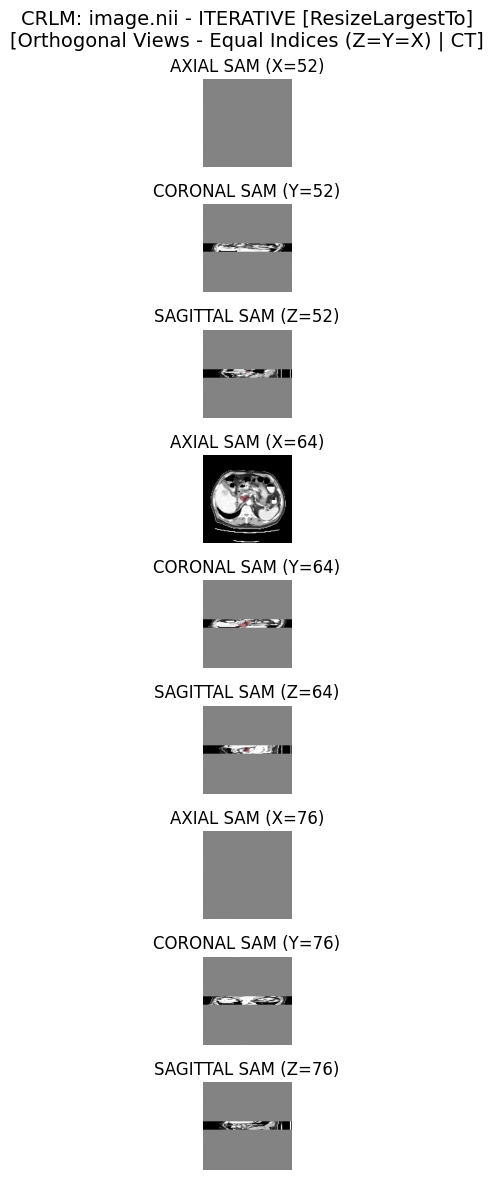

  📸 Plotting UNPROMPTED segmentation [Modality: CT]...

📊 Orthogonal Views: CRLM: image.nii - UNPROMPTED [ResizeLargestTo]
Volume shape: (D=128, H=128, W=128)
Display window: [-126.45, 119.84]
Selected 3D points (Z=Y=X): [(52, 52, 52), (64, 64, 64), (76, 76, 76)]


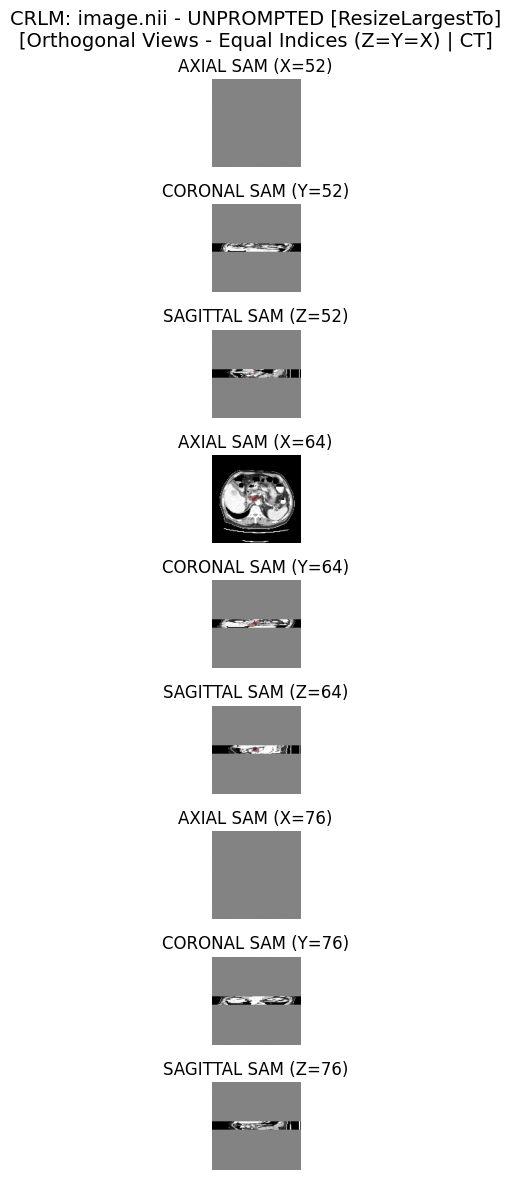


Processing: image.nii.gz
  Loading image for SAM (WITH normalization)...
  Loading image for display (NO normalization)...
  Loading ground truth mask...
    SAM input shape: torch.Size([1, 1, 128, 128, 128])
    Display shape: (128, 128, 128)

  🎯 Generating PROMPTED SAM segmentation (iterative refinement with 11 clicks)...
    🔄 Iterative Refinement with 11 clicks
      Click 1/11: Dice = 0.0000
      Click 3/11: Dice = 0.0000
      Click 6/11: Dice = 0.0000
      Click 9/11: Dice = 0.0000
      Click 11/11: Dice = 0.0000
    ✅ Final Dice: 0.0000 | Voxels: 1349
    Prompted segmentation: 1349 voxels

  🎯 Generating UNPROMPTED SAM segmentation (center point only)...
    Using CENTER point (unprompted): (64, 64, 64)
    Unprompted segmentation stats: min=0.000, max=0.999, threshold=0.5, voxels=3838
    Unprompted segmentation: 3838 voxels

  📸 Plotting PROMPTED segmentation [Modality: CT]...

📊 Orthogonal Views: CRLM: image.nii - ITERATIVE [ResizeLargestTo]
Volume shape: (D=128, H=128

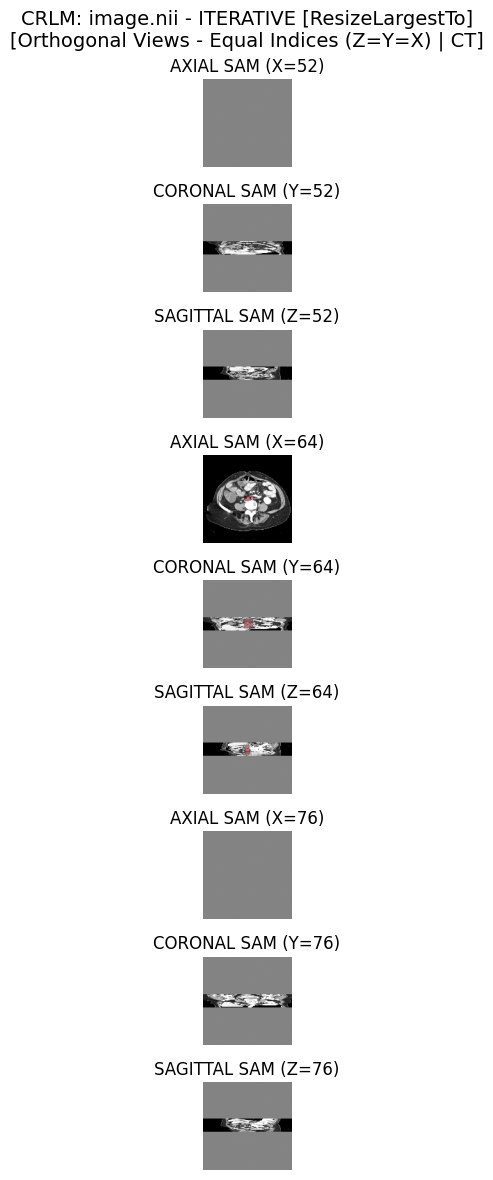

  📸 Plotting UNPROMPTED segmentation [Modality: CT]...

📊 Orthogonal Views: CRLM: image.nii - UNPROMPTED [ResizeLargestTo]
Volume shape: (D=128, H=128, W=128)
Display window: [-149.71, 138.72]
Selected 3D points (Z=Y=X): [(52, 52, 52), (64, 64, 64), (76, 76, 76)]


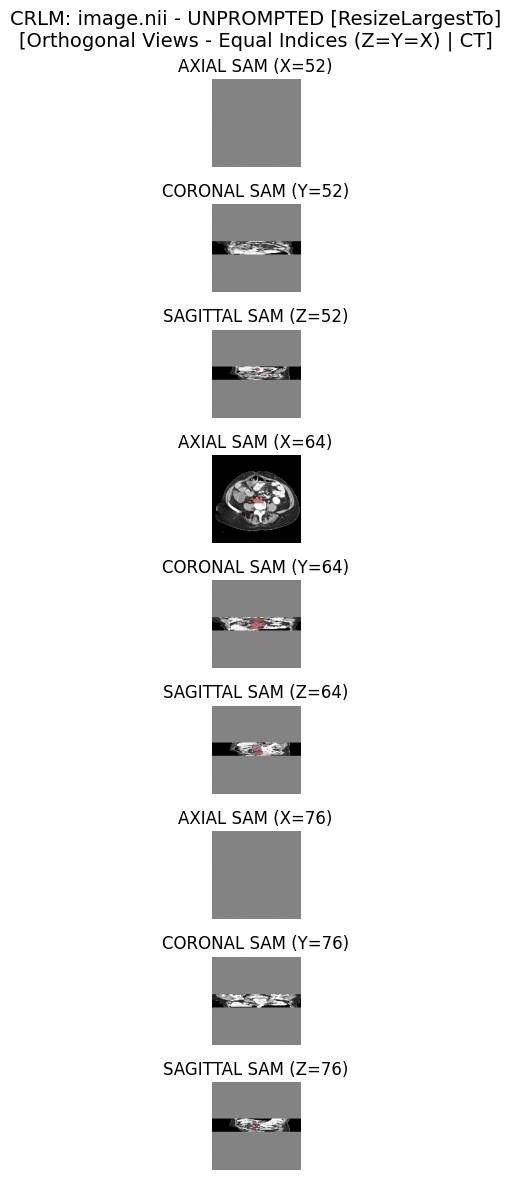


Processing dataset: DESMOID [ResizeLargestTo]
Found 203 images

🔍 Visualizing and computing dice for 2 sample(s)

Processing: image.nii.gz
  Loading image for SAM (WITH normalization)...
  Loading image for display (NO normalization)...
  Loading ground truth mask...
    SAM input shape: torch.Size([1, 1, 128, 128, 128])
    Display shape: (128, 128, 128)
    Mask shape: (128, 128, 128)
    Mask sum: 53.0 voxels

  🎯 Generating PROMPTED SAM segmentation (iterative refinement with 11 clicks)...
    🔄 Iterative Refinement with 11 clicks
      Click 1/11: Dice = 0.0001
      Click 3/11: Dice = 0.0001
      Click 6/11: Dice = 0.0001
      Click 9/11: Dice = 0.0001
      Click 11/11: Dice = 0.0001
    ✅ Final Dice: 0.1282 | Voxels: 774
    Prompted segmentation: 774 voxels

  🎯 Generating UNPROMPTED SAM segmentation (center point only)...
    Using CENTER point (unprompted): (64, 64, 64)
    Unprompted segmentation stats: min=0.000, max=0.999, threshold=0.5, voxels=1510
    Unprompted segm

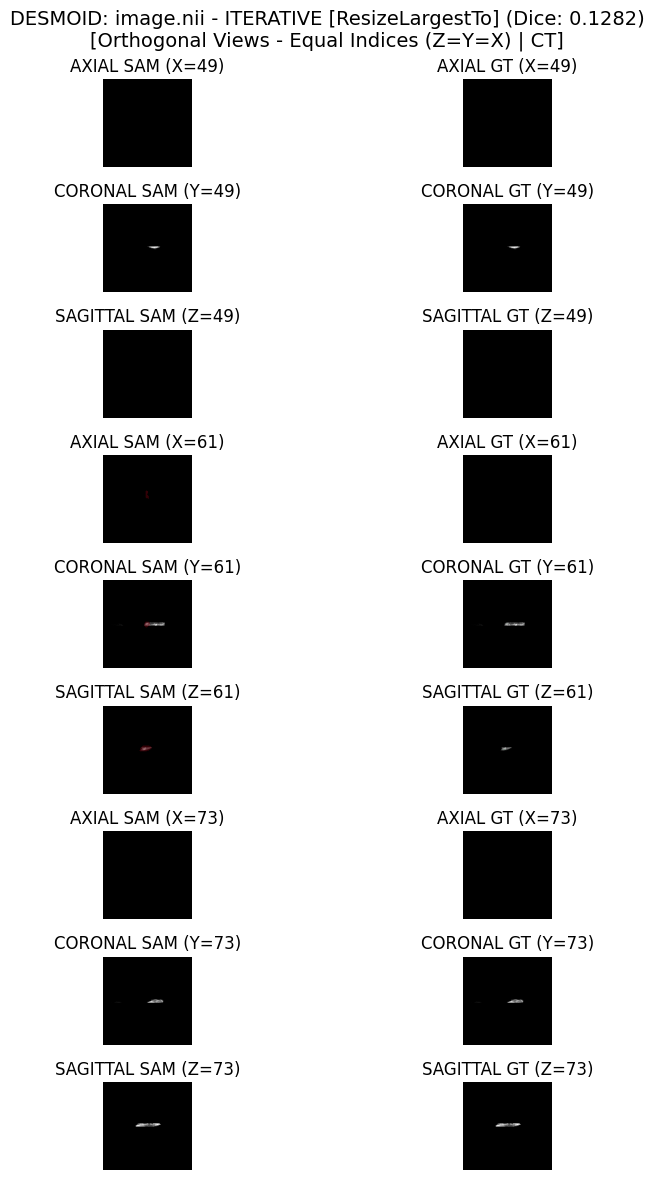

  📸 Plotting UNPROMPTED segmentation [Modality: CT]...

📊 Orthogonal Views: DESMOID: image.nii - UNPROMPTED [ResizeLargestTo] (Dice: 0.0678)
Volume shape: (D=128, H=128, W=128)
Display window: [5154.38, 73756.70]
Selected 3D points (Z=Y=X): [(49, 49, 49), (61, 61, 61), (73, 73, 73)]


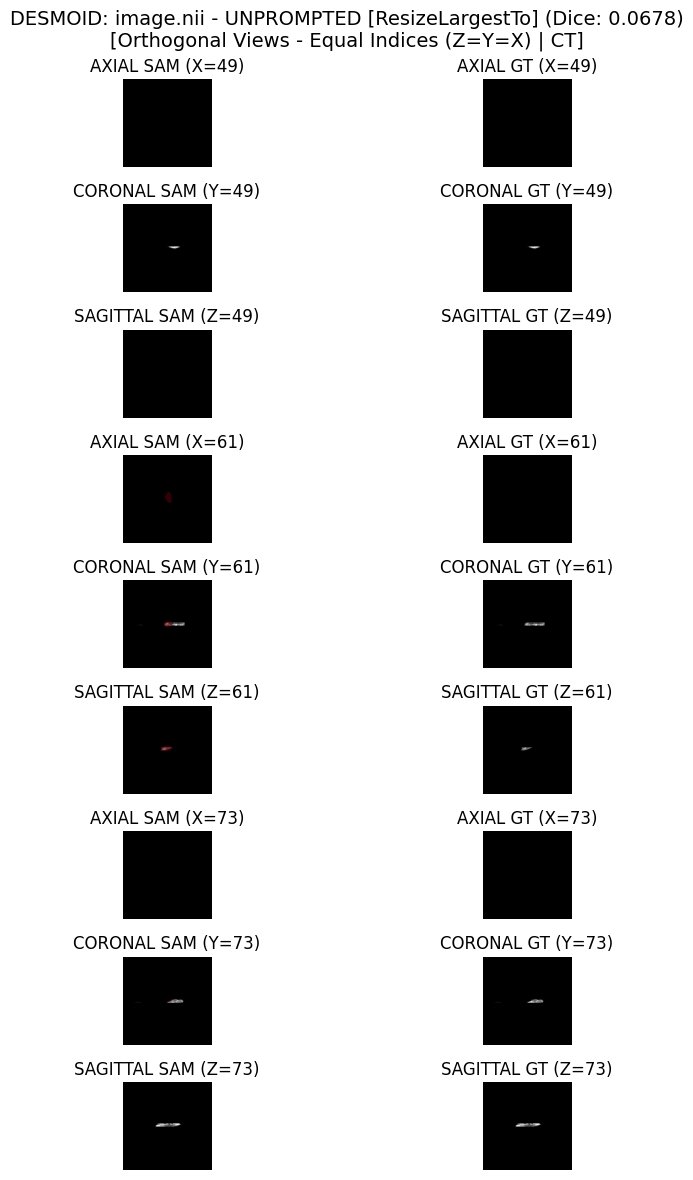


Processing: image.nii.gz
  Loading image for SAM (WITH normalization)...
  Loading image for display (NO normalization)...
  Loading ground truth mask...
    SAM input shape: torch.Size([1, 1, 128, 128, 128])
    Display shape: (128, 128, 128)
    Mask shape: (128, 128, 128)
    Mask sum: 475.0 voxels

  🎯 Generating PROMPTED SAM segmentation (iterative refinement with 11 clicks)...
    🔄 Iterative Refinement with 11 clicks
      Click 1/11: Dice = 0.0005
      Click 3/11: Dice = 0.0005
      Click 6/11: Dice = 0.0005
      Click 9/11: Dice = 0.0005
      Click 11/11: Dice = 0.0005
    ✅ Final Dice: 0.0000 | Voxels: 9851
    Prompted segmentation: 9851 voxels

  🎯 Generating UNPROMPTED SAM segmentation (center point only)...
    Using CENTER point (unprompted): (64, 64, 64)
    Unprompted segmentation stats: min=0.000, max=0.999, threshold=0.5, voxels=1397
    Unprompted segmentation: 1397 voxels

  📊 DICE SCORES [ResizeLargestTo]:
     Prompted (11-click iterative):   0.0000
     Unp

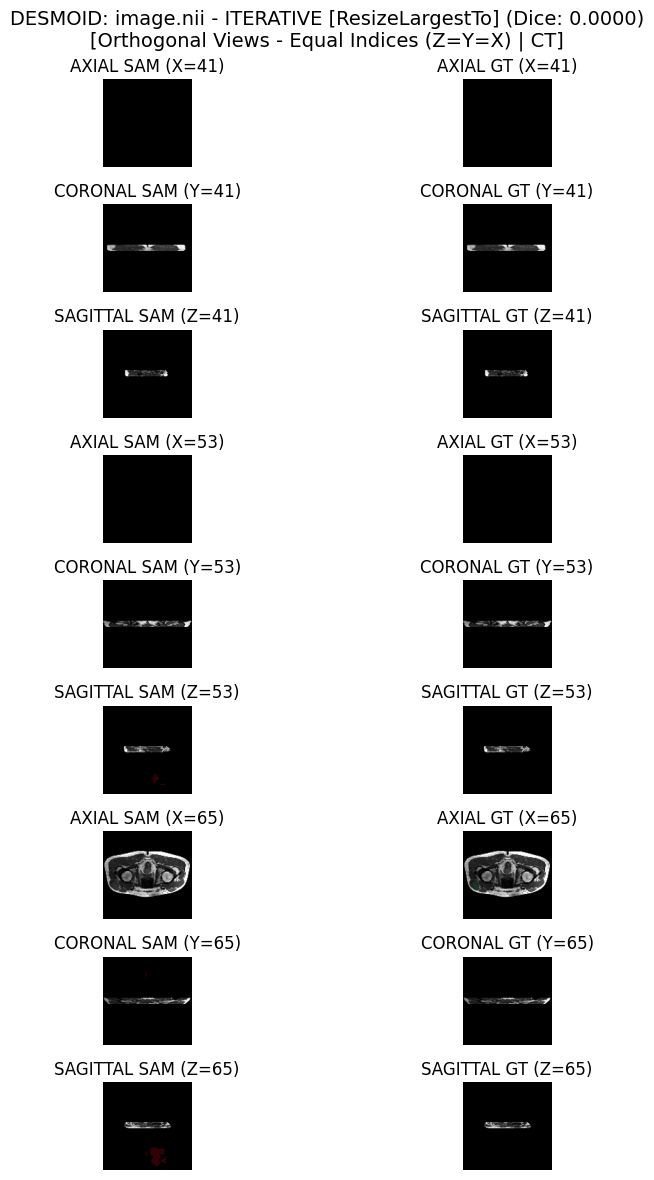

  📸 Plotting UNPROMPTED segmentation [Modality: CT]...

📊 Orthogonal Views: DESMOID: image.nii - UNPROMPTED [ResizeLargestTo] (Dice: 0.0000)
Volume shape: (D=128, H=128, W=128)
Display window: [119478.38, 964908.62]
Selected 3D points (Z=Y=X): [(41, 41, 41), (53, 53, 53), (65, 65, 65)]


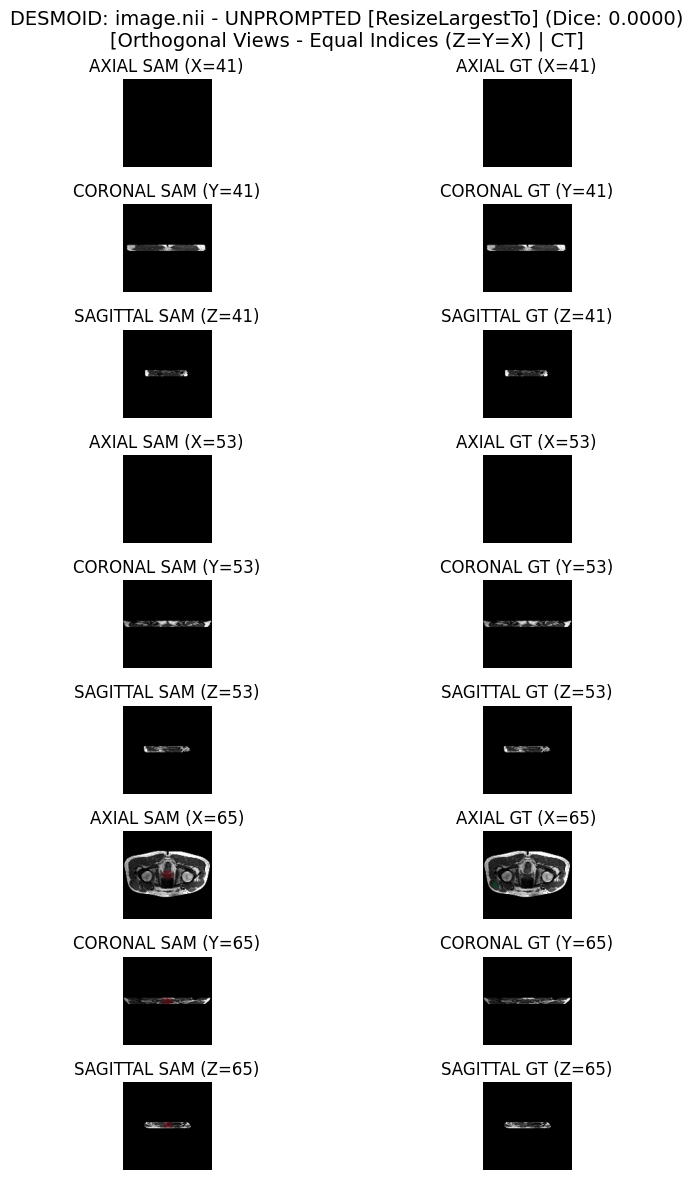


Processing dataset: GIST [ResizeLargestTo]
Found 245 images

🔍 Visualizing and computing dice for 2 sample(s)

Processing: image.nii.gz
  Loading image for SAM (WITH normalization)...
  Loading image for display (NO normalization)...
  Loading ground truth mask...
    SAM input shape: torch.Size([1, 1, 128, 128, 128])
    Display shape: (128, 128, 128)
    Mask shape: (128, 128, 128)
    Mask sum: 22826.0 voxels

  🎯 Generating PROMPTED SAM segmentation (iterative refinement with 11 clicks)...
    🔄 Iterative Refinement with 11 clicks
      Click 1/11: Dice = 0.0215
      Click 3/11: Dice = 0.0215
      Click 6/11: Dice = 0.0215
      Click 9/11: Dice = 0.0215
      Click 11/11: Dice = 0.0215
    ✅ Final Dice: 0.3871 | Voxels: 7394
    Prompted segmentation: 7394 voxels

  🎯 Generating UNPROMPTED SAM segmentation (center point only)...
    Using CENTER point (unprompted): (64, 64, 64)
    Unprompted segmentation stats: min=0.000, max=0.993, threshold=0.5, voxels=1294
    Unprompted se

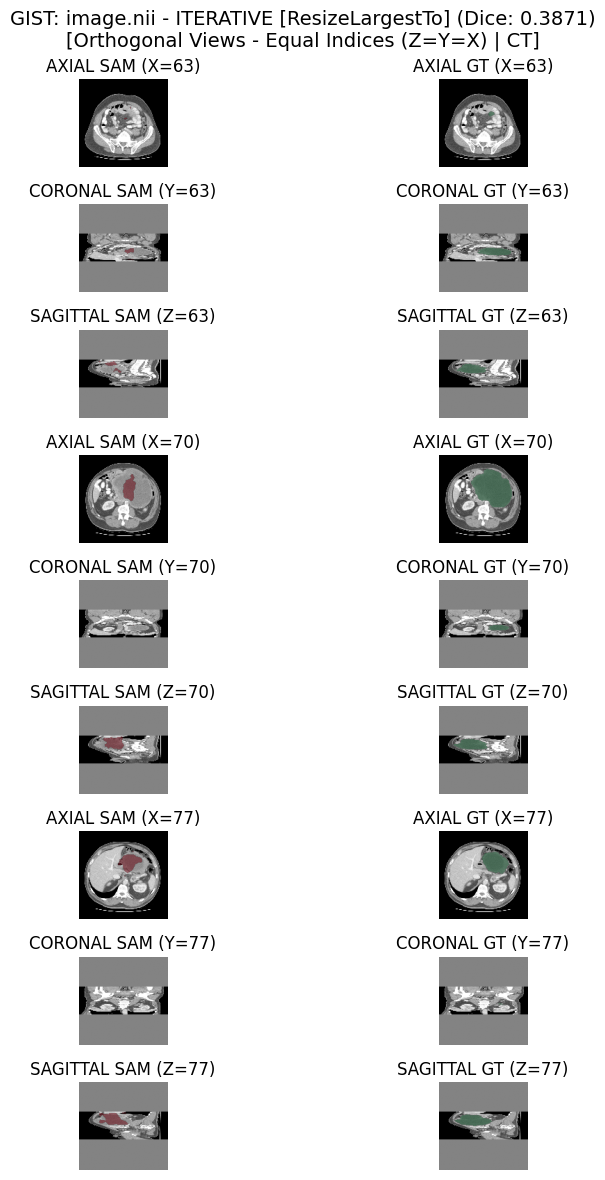

  📸 Plotting UNPROMPTED segmentation [Modality: CT]...

📊 Orthogonal Views: GIST: image.nii - UNPROMPTED [ResizeLargestTo] (Dice: 0.0051)
Volume shape: (D=128, H=128, W=128)
Display window: [-227.59, 215.19]
Selected 3D points (Z=Y=X): [(63, 63, 63), (70, 70, 70), (77, 77, 77)]


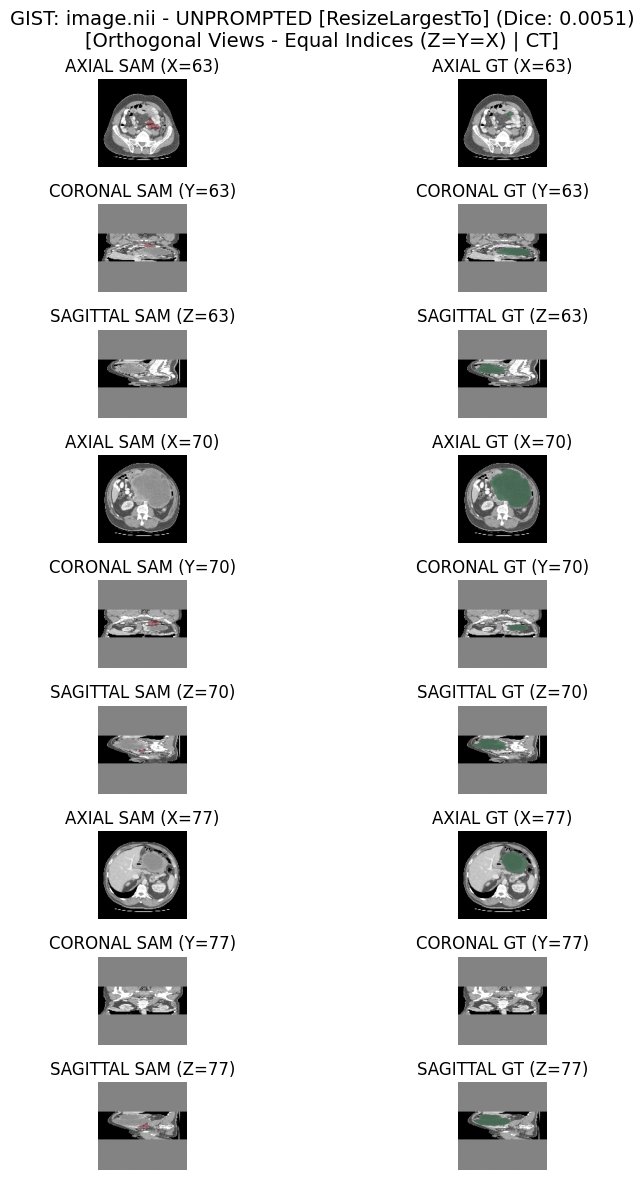


Processing: image.nii.gz
  Loading image for SAM (WITH normalization)...
  Loading image for display (NO normalization)...
  Loading ground truth mask...
    SAM input shape: torch.Size([1, 1, 128, 128, 128])
    Display shape: (128, 128, 128)
    Mask shape: (128, 128, 128)
    Mask sum: 1704.0 voxels

  🎯 Generating PROMPTED SAM segmentation (iterative refinement with 11 clicks)...
    🔄 Iterative Refinement with 11 clicks
      Click 1/11: Dice = 0.0016
      Click 3/11: Dice = 0.0016
      Click 6/11: Dice = 0.0016
      Click 9/11: Dice = 0.0016
      Click 11/11: Dice = 0.0016
    ✅ Final Dice: 0.0777 | Voxels: 1229
    Prompted segmentation: 1229 voxels

  🎯 Generating UNPROMPTED SAM segmentation (center point only)...
    Using CENTER point (unprompted): (64, 64, 64)
    Unprompted segmentation stats: min=0.000, max=0.987, threshold=0.5, voxels=1245
    Unprompted segmentation: 1245 voxels

  📊 DICE SCORES [ResizeLargestTo]:
     Prompted (11-click iterative):   0.0777
     Un

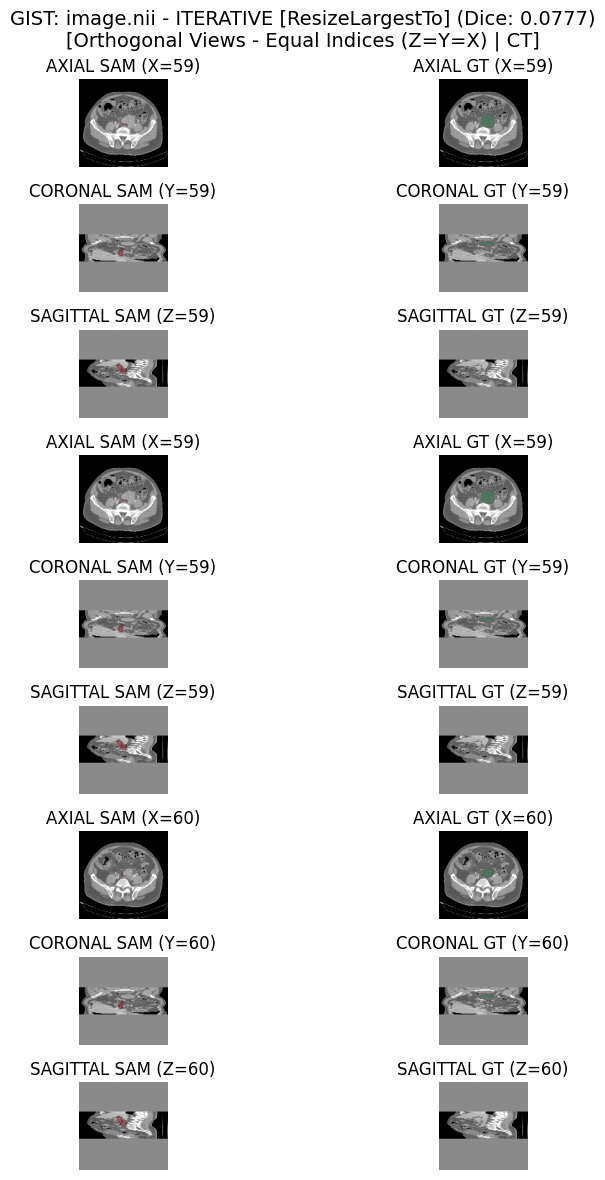

  📸 Plotting UNPROMPTED segmentation [Modality: CT]...

📊 Orthogonal Views: GIST: image.nii - UNPROMPTED [ResizeLargestTo] (Dice: 0.2211)
Volume shape: (D=128, H=128, W=128)
Display window: [-329.71, 280.34]
Selected 3D points (Z=Y=X): [(59, 59, 59), (59, 59, 59), (60, 60, 60)]


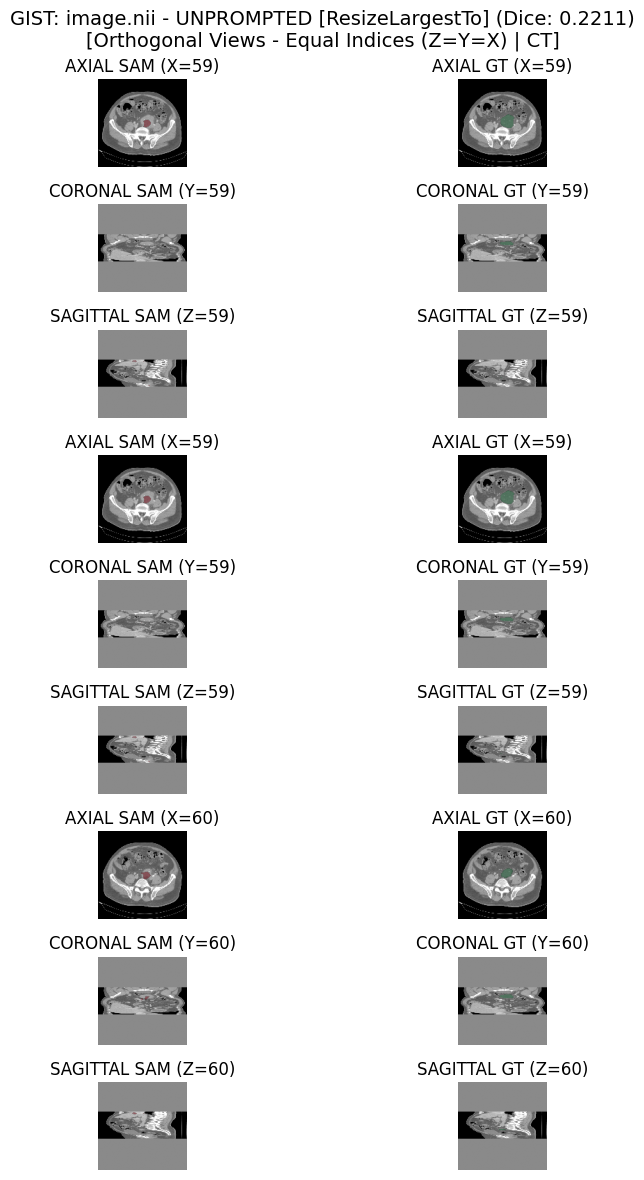


Processing dataset: LIPO [ResizeLargestTo]
Found 115 images

🔍 Visualizing and computing dice for 2 sample(s)

Processing: image.nii.gz
  Loading image for SAM (WITH normalization)...
  Loading image for display (NO normalization)...
  Loading ground truth mask...
    SAM input shape: torch.Size([1, 1, 128, 128, 128])
    Display shape: (128, 128, 128)
    Mask shape: (128, 128, 128)
    Mask sum: 6318.0 voxels

  🎯 Generating PROMPTED SAM segmentation (iterative refinement with 11 clicks)...
    🔄 Iterative Refinement with 11 clicks
      Click 1/11: Dice = 0.0060
      Click 3/11: Dice = 0.0060
      Click 6/11: Dice = 0.0060
      Click 9/11: Dice = 0.0060
      Click 11/11: Dice = 0.0060
    ✅ Final Dice: 0.1065 | Voxels: 2036
    Prompted segmentation: 2036 voxels

  🎯 Generating UNPROMPTED SAM segmentation (center point only)...
    Using CENTER point (unprompted): (64, 64, 64)
    Unprompted segmentation stats: min=0.000, max=0.999, threshold=0.5, voxels=6300
    Unprompted seg

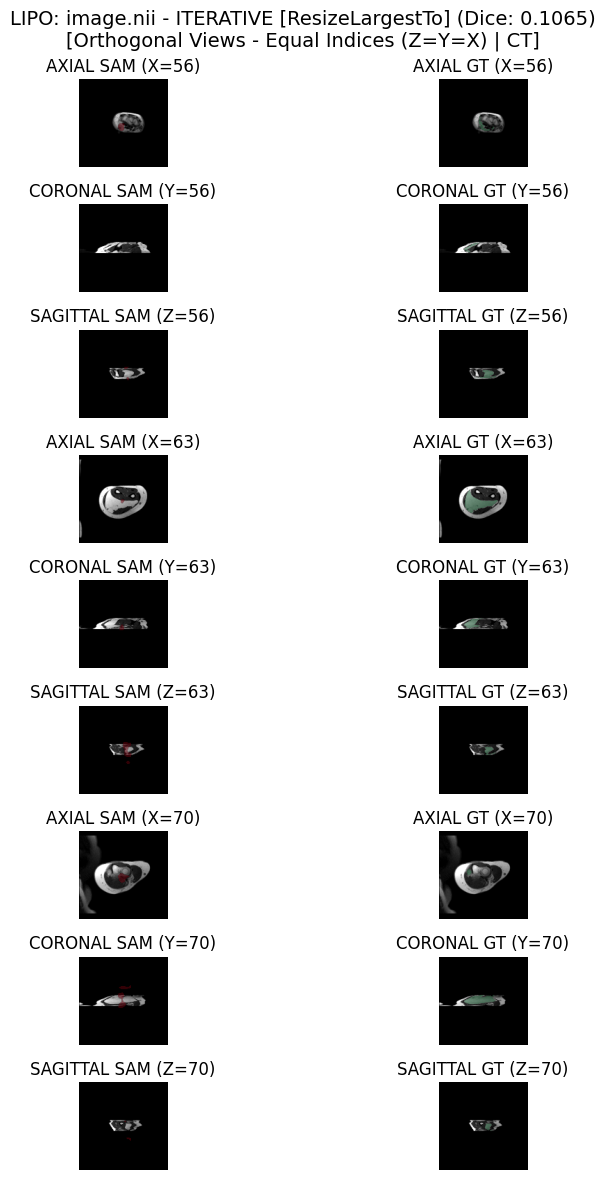

  📸 Plotting UNPROMPTED segmentation [Modality: CT]...

📊 Orthogonal Views: LIPO: image.nii - UNPROMPTED [ResizeLargestTo] (Dice: 0.2381)
Volume shape: (D=128, H=128, W=128)
Display window: [105.00, 1385.29]
Selected 3D points (Z=Y=X): [(56, 56, 56), (63, 63, 63), (70, 70, 70)]


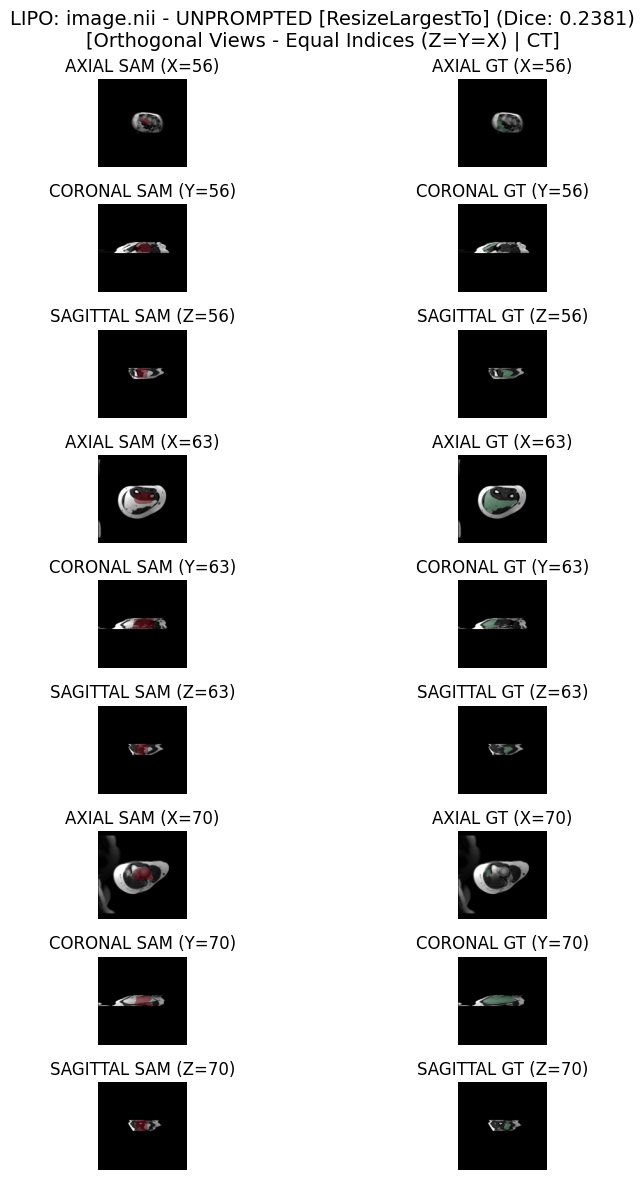


Processing: image.nii.gz
  Loading image for SAM (WITH normalization)...
  Loading image for display (NO normalization)...
  Loading ground truth mask...
    SAM input shape: torch.Size([1, 1, 128, 128, 128])
    Display shape: (128, 128, 128)
    Mask shape: (128, 128, 128)
    Mask sum: 4922.0 voxels

  🎯 Generating PROMPTED SAM segmentation (iterative refinement with 11 clicks)...
    🔄 Iterative Refinement with 11 clicks
      Click 1/11: Dice = 0.0047
      Click 3/11: Dice = 0.0047
      Click 6/11: Dice = 0.0047
      Click 9/11: Dice = 0.0047
      Click 11/11: Dice = 0.0047
    ✅ Final Dice: 0.0000 | Voxels: 2128
    Prompted segmentation: 2128 voxels

  🎯 Generating UNPROMPTED SAM segmentation (center point only)...
    Using CENTER point (unprompted): (64, 64, 64)
    Unprompted segmentation stats: min=0.000, max=0.994, threshold=0.5, voxels=1062
    Unprompted segmentation: 1062 voxels

  📊 DICE SCORES [ResizeLargestTo]:
     Prompted (11-click iterative):   0.0000
     Un

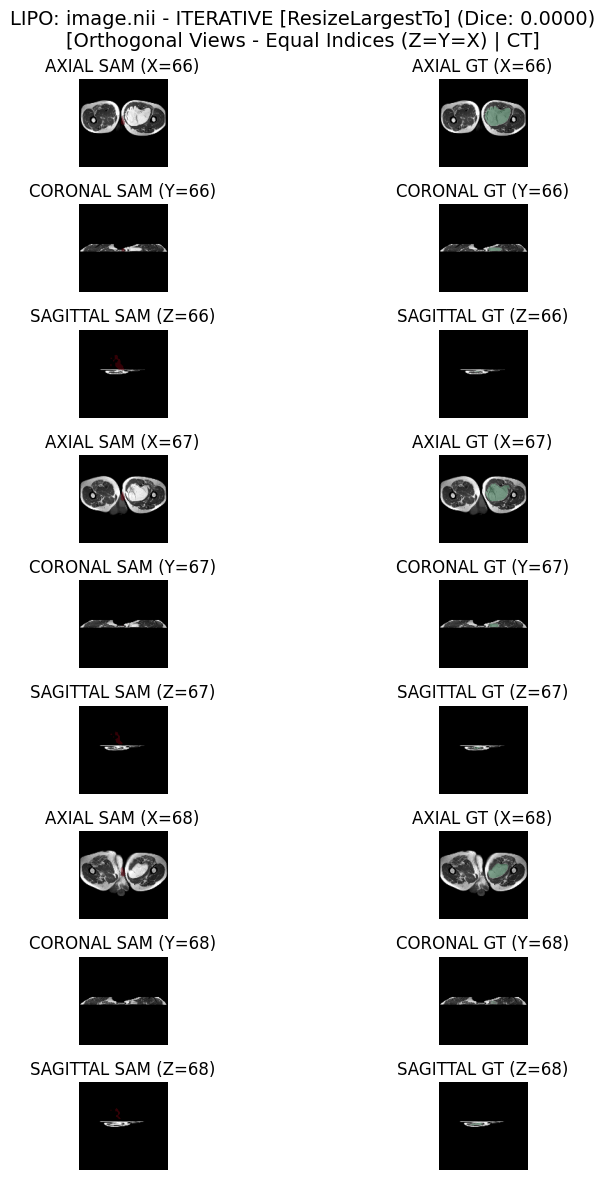

  📸 Plotting UNPROMPTED segmentation [Modality: CT]...

📊 Orthogonal Views: LIPO: image.nii - UNPROMPTED [ResizeLargestTo] (Dice: 0.0090)
Volume shape: (D=128, H=128, W=128)
Display window: [77.00, 835.76]
Selected 3D points (Z=Y=X): [(66, 66, 66), (67, 67, 67), (68, 68, 68)]


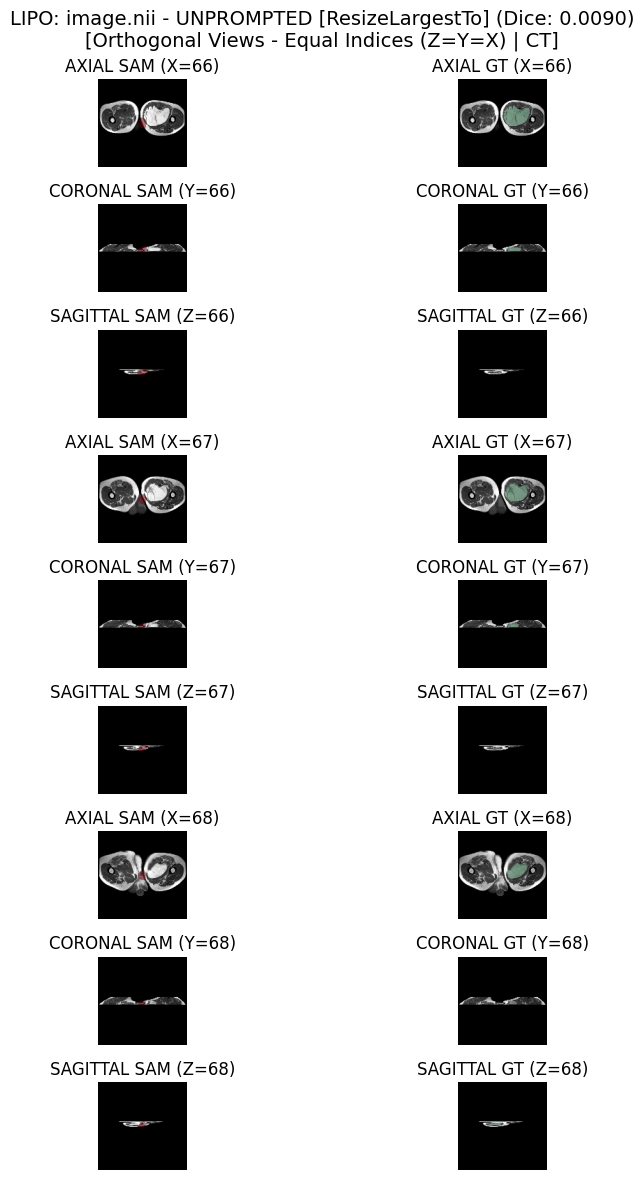


Processing dataset: LIVER [ResizeLargestTo]
Found 186 images

🔍 Visualizing and computing dice for 2 sample(s)

Processing: image.nii.gz
  Loading image for SAM (WITH normalization)...
  Loading image for display (NO normalization)...
  Loading ground truth mask...
    SAM input shape: torch.Size([1, 1, 128, 128, 128])
    Display shape: (128, 128, 128)
    Mask shape: (128, 128, 128)
    Mask sum: 639.0 voxels

  🎯 Generating PROMPTED SAM segmentation (iterative refinement with 11 clicks)...
    🔄 Iterative Refinement with 11 clicks
      Click 1/11: Dice = 0.0006
      Click 3/11: Dice = 0.0006
      Click 6/11: Dice = 0.0006
      Click 9/11: Dice = 0.0006
      Click 11/11: Dice = 0.0006
    ✅ Final Dice: 0.0000 | Voxels: 5480
    Prompted segmentation: 5480 voxels

  🎯 Generating UNPROMPTED SAM segmentation (center point only)...
    Using CENTER point (unprompted): (64, 64, 64)
    Unprompted segmentation stats: min=0.000, max=1.000, threshold=0.5, voxels=1375
    Unprompted seg

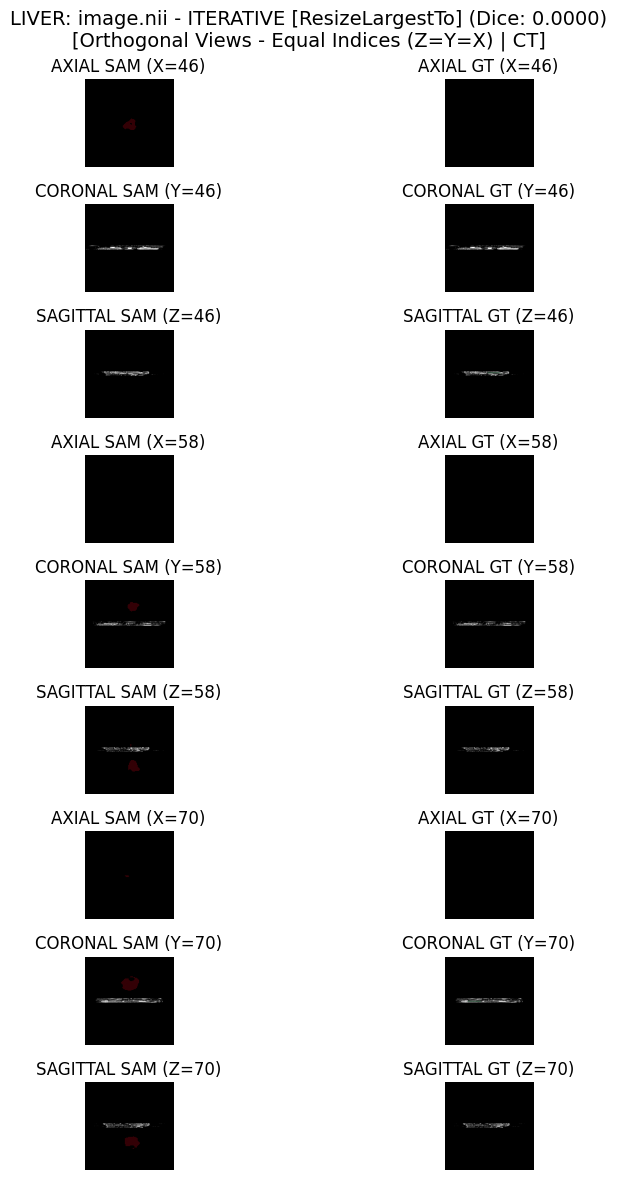

  📸 Plotting UNPROMPTED segmentation [Modality: CT]...

📊 Orthogonal Views: LIVER: image.nii - UNPROMPTED [ResizeLargestTo] (Dice: 0.0000)
Volume shape: (D=128, H=128, W=128)
Display window: [140.00, 806.18]
Selected 3D points (Z=Y=X): [(46, 46, 46), (58, 58, 58), (70, 70, 70)]


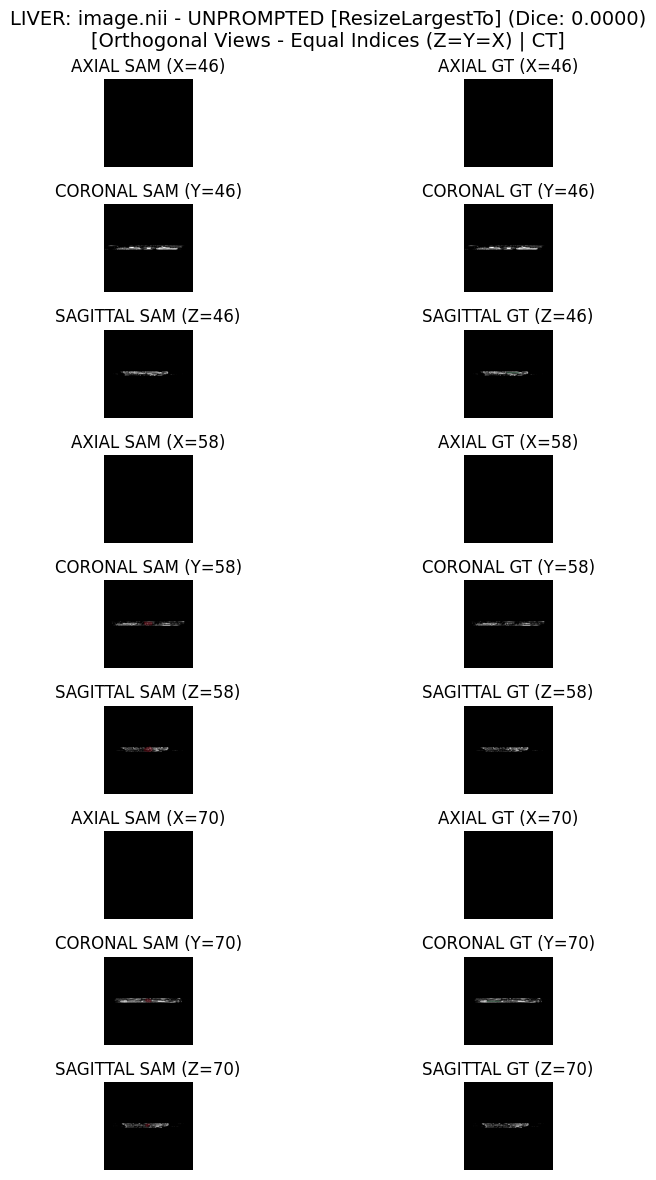


Processing: image.nii.gz
  Loading image for SAM (WITH normalization)...
  Loading image for display (NO normalization)...
  Loading ground truth mask...
    SAM input shape: torch.Size([1, 1, 128, 128, 128])
    Display shape: (128, 128, 128)
    Mask shape: (128, 128, 128)
    Mask sum: 63.0 voxels

  🎯 Generating PROMPTED SAM segmentation (iterative refinement with 11 clicks)...
    🔄 Iterative Refinement with 11 clicks
      Click 1/11: Dice = 0.0001
      Click 3/11: Dice = 0.0001
      Click 6/11: Dice = 0.0001
      Click 9/11: Dice = 0.0001
      Click 11/11: Dice = 0.0001
    ✅ Final Dice: 0.1794 | Voxels: 528
    Prompted segmentation: 528 voxels

  🎯 Generating UNPROMPTED SAM segmentation (center point only)...
    Using CENTER point (unprompted): (64, 64, 64)
    Unprompted segmentation stats: min=0.000, max=0.999, threshold=0.5, voxels=1880
    Unprompted segmentation: 1880 voxels

  📊 DICE SCORES [ResizeLargestTo]:
     Prompted (11-click iterative):   0.1794
     Unprom

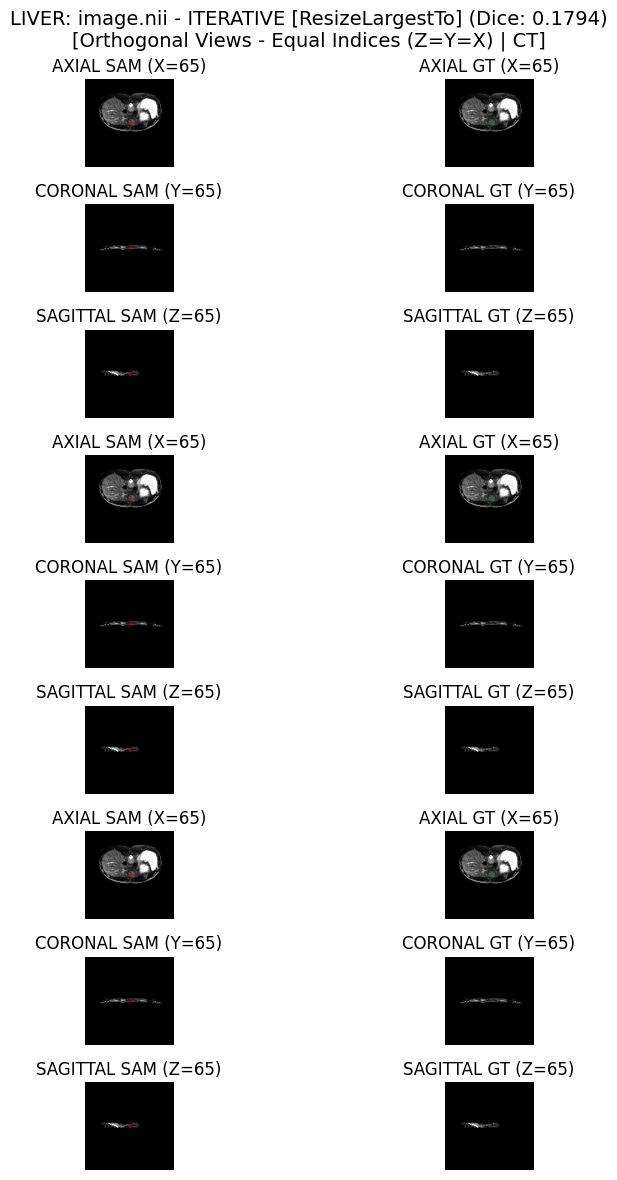

  📸 Plotting UNPROMPTED segmentation [Modality: CT]...

📊 Orthogonal Views: LIVER: image.nii - UNPROMPTED [ResizeLargestTo] (Dice: 0.0648)
Volume shape: (D=128, H=128, W=128)
Display window: [32.00, 188.56]
Selected 3D points (Z=Y=X): [(65, 65, 65), (65, 65, 65), (65, 65, 65)]


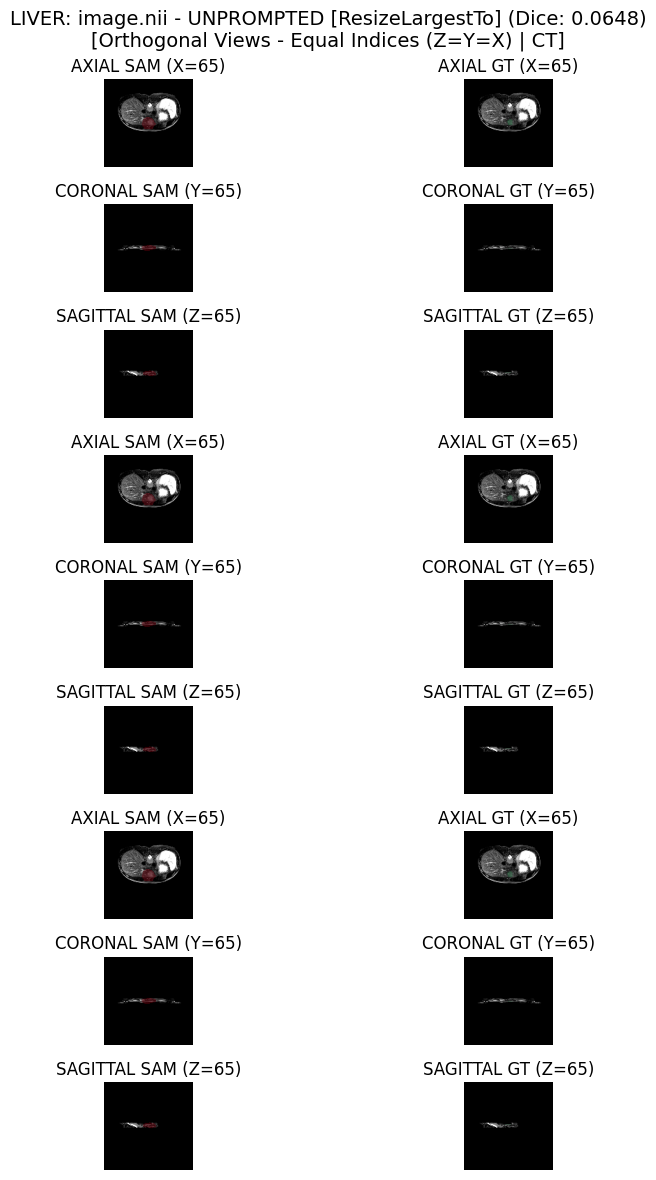


Processing dataset: MELANOMA [ResizeLargestTo]
Found 103 images

🔍 Visualizing and computing dice for 2 sample(s)

Processing: image.nii.gz
  Loading image for SAM (WITH normalization)...
  Loading image for display (NO normalization)...
  Loading ground truth mask...
    SAM input shape: torch.Size([1, 1, 128, 128, 128])
    Display shape: (128, 128, 128)

  🎯 Generating PROMPTED SAM segmentation (iterative refinement with 11 clicks)...
    🔄 Iterative Refinement with 11 clicks
      Click 1/11: Dice = 0.0000
      Click 3/11: Dice = 0.0000
      Click 6/11: Dice = 0.0000
      Click 9/11: Dice = 0.0000
      Click 11/11: Dice = 0.0000
    ✅ Final Dice: 0.0000 | Voxels: 1070
    Prompted segmentation: 1070 voxels

  🎯 Generating UNPROMPTED SAM segmentation (center point only)...
    Using CENTER point (unprompted): (64, 64, 64)
    Unprompted segmentation stats: min=0.000, max=0.985, threshold=0.5, voxels=2395
    Unprompted segmentation: 2395 voxels

  📸 Plotting PROMPTED segmentati

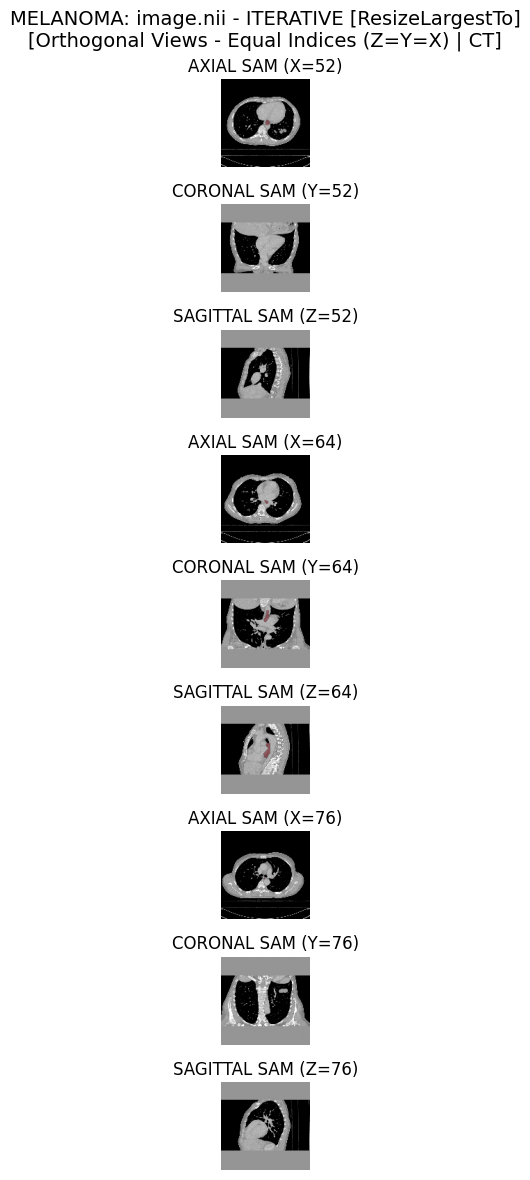

  📸 Plotting UNPROMPTED segmentation [Modality: CT]...

📊 Orthogonal Views: MELANOMA: image.nii - UNPROMPTED [ResizeLargestTo]
Volume shape: (D=128, H=128, W=128)
Display window: [-683.12, 486.81]
Selected 3D points (Z=Y=X): [(52, 52, 52), (64, 64, 64), (76, 76, 76)]


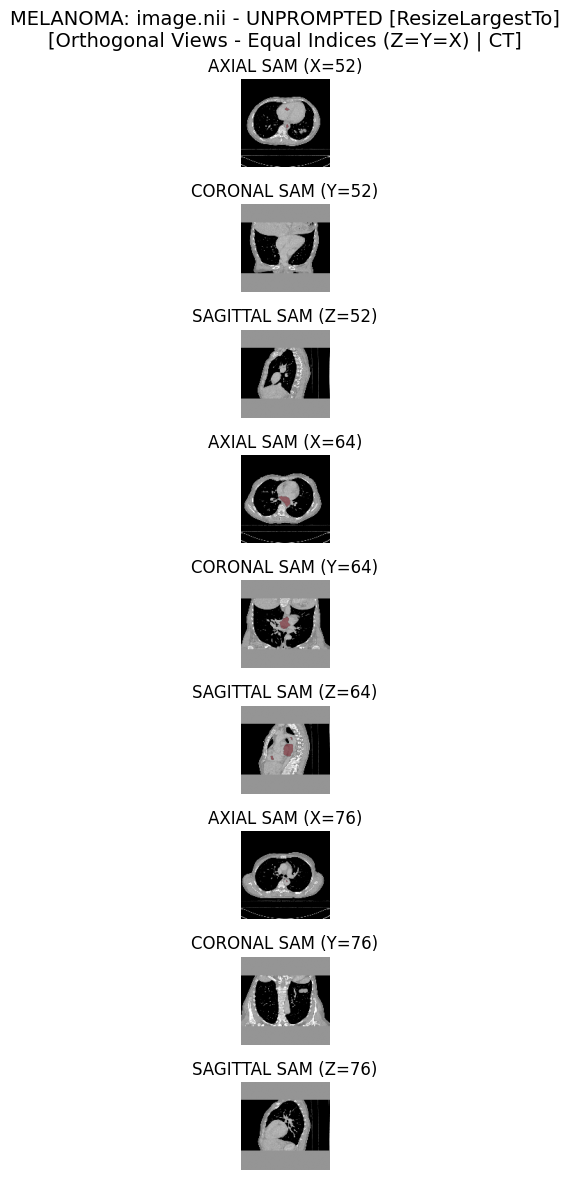


Processing: image.nii.gz
  Loading image for SAM (WITH normalization)...
  Loading image for display (NO normalization)...
  Loading ground truth mask...
    SAM input shape: torch.Size([1, 1, 128, 128, 128])
    Display shape: (128, 128, 128)

  🎯 Generating PROMPTED SAM segmentation (iterative refinement with 11 clicks)...
    🔄 Iterative Refinement with 11 clicks
      Click 1/11: Dice = 0.0000
      Click 3/11: Dice = 0.0000
      Click 6/11: Dice = 0.0000
      Click 9/11: Dice = 0.0000
      Click 11/11: Dice = 0.0000
    ✅ Final Dice: 0.0000 | Voxels: 687
    Prompted segmentation: 687 voxels

  🎯 Generating UNPROMPTED SAM segmentation (center point only)...
    Using CENTER point (unprompted): (64, 64, 64)
    Unprompted segmentation stats: min=0.000, max=0.998, threshold=0.5, voxels=10695
    Unprompted segmentation: 10695 voxels

  📸 Plotting PROMPTED segmentation [Modality: CT]...

📊 Orthogonal Views: MELANOMA: image.nii - ITERATIVE [ResizeLargestTo]
Volume shape: (D=128, H

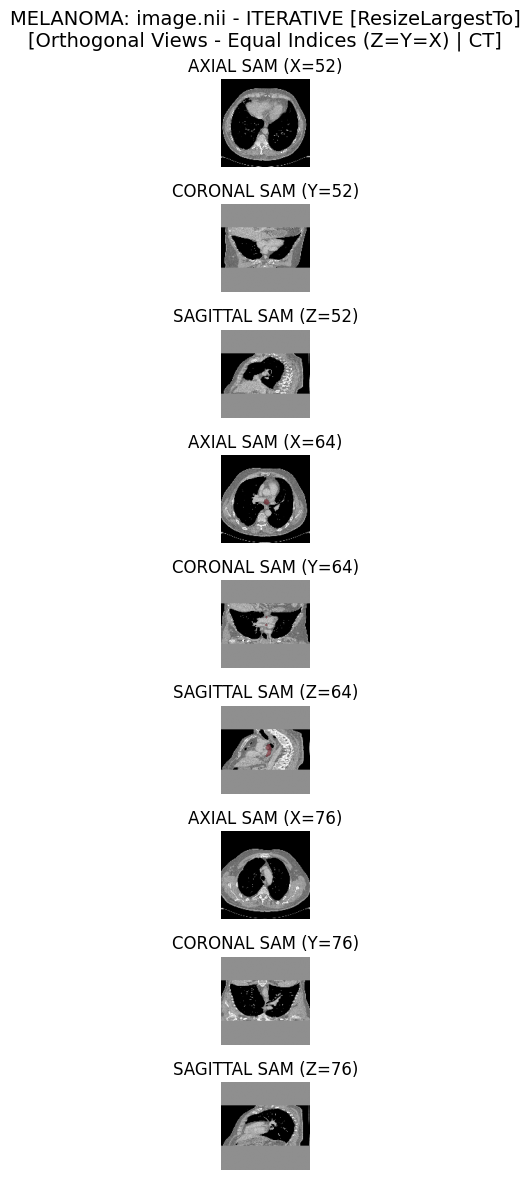

  📸 Plotting UNPROMPTED segmentation [Modality: CT]...

📊 Orthogonal Views: MELANOMA: image.nii - UNPROMPTED [ResizeLargestTo]
Volume shape: (D=128, H=128, W=128)
Display window: [-467.91, 369.50]
Selected 3D points (Z=Y=X): [(52, 52, 52), (64, 64, 64), (76, 76, 76)]


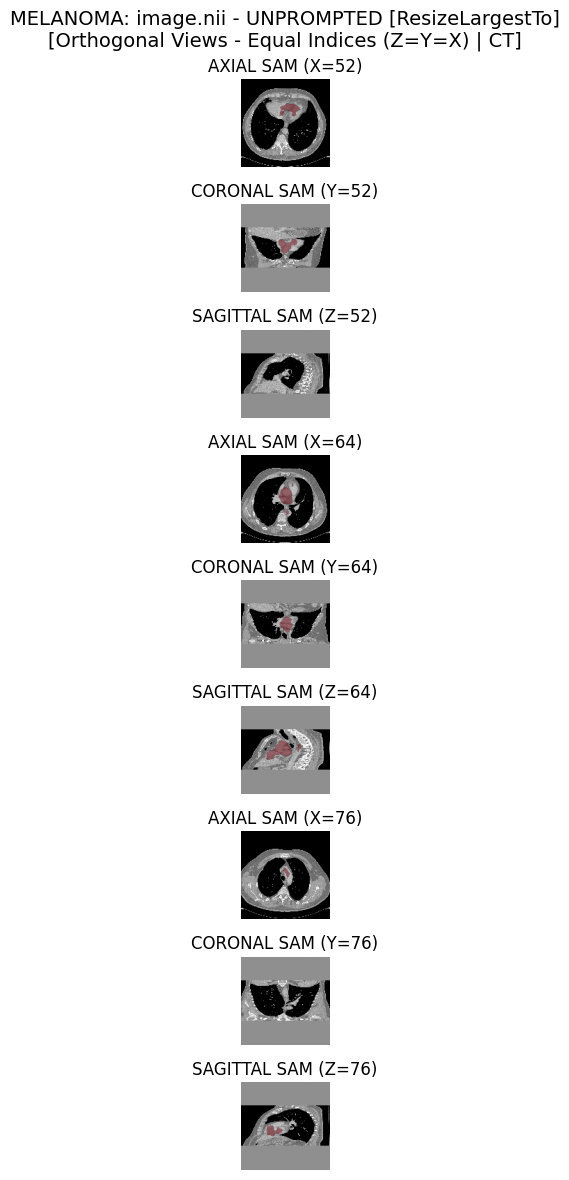


🔬 PREPROCESSING STRATEGY: ROI-Cropped
   • ROI-cropped with 30px margin
   • Tumor-centered volumes
   • Better for small lesions

Processing dataset: CRLM [ROI-Cropped]
Found 77 images

🔍 Visualizing and computing dice for 2 sample(s)

Processing: image.nii.gz
  Loading image for SAM (WITH normalization)...
  Loading image for display (NO normalization)...
  Loading ground truth mask...
    SAM input shape: torch.Size([1, 1, 128, 128, 128])
    Display shape: (128, 128, 128)

  🎯 Generating PROMPTED SAM segmentation (iterative refinement with 11 clicks)...
    🔄 Iterative Refinement with 11 clicks
      Click 1/11: Dice = 0.0000
      Click 3/11: Dice = 0.0000
      Click 6/11: Dice = 0.0000
      Click 9/11: Dice = 0.0000
      Click 11/11: Dice = 0.0000
    ✅ Final Dice: 0.0000 | Voxels: 739
    Prompted segmentation: 739 voxels

  🎯 Generating UNPROMPTED SAM segmentation (center point only)...
    Using CENTER point (unprompted): (64, 64, 64)
    Unprompted segmentation stats: min

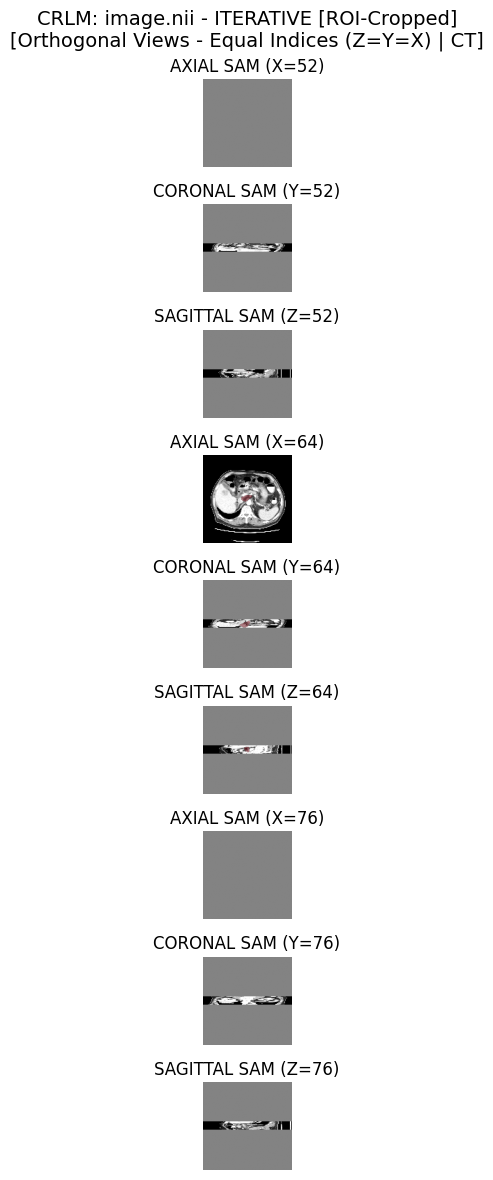

  📸 Plotting UNPROMPTED segmentation [Modality: CT]...

📊 Orthogonal Views: CRLM: image.nii - UNPROMPTED [ROI-Cropped]
Volume shape: (D=128, H=128, W=128)
Display window: [-126.45, 119.84]
Selected 3D points (Z=Y=X): [(52, 52, 52), (64, 64, 64), (76, 76, 76)]


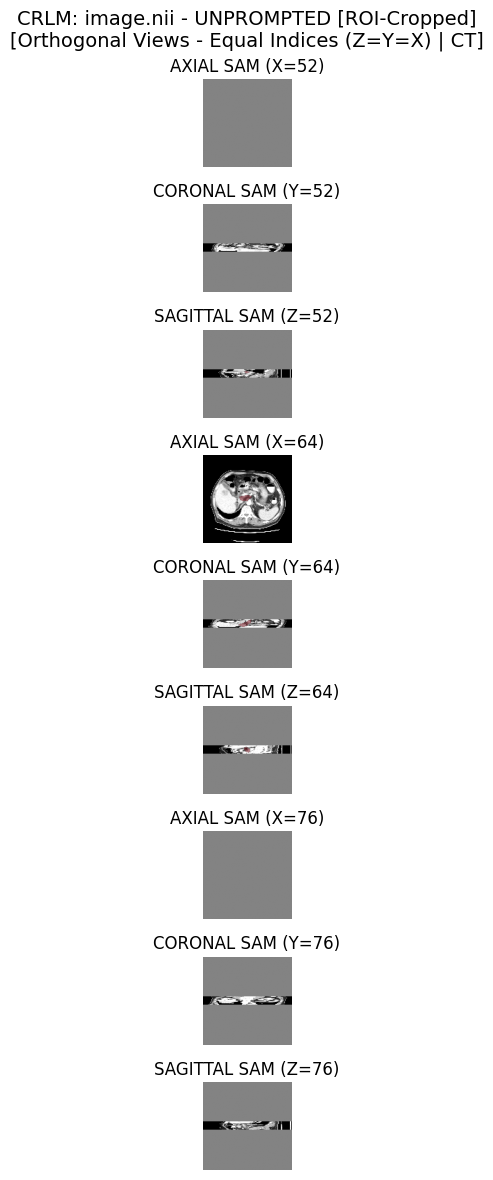


Processing: image.nii.gz
  Loading image for SAM (WITH normalization)...
  Loading image for display (NO normalization)...
  Loading ground truth mask...
    SAM input shape: torch.Size([1, 1, 128, 128, 128])
    Display shape: (128, 128, 128)

  🎯 Generating PROMPTED SAM segmentation (iterative refinement with 11 clicks)...
    🔄 Iterative Refinement with 11 clicks
      Click 1/11: Dice = 0.0000
      Click 3/11: Dice = 0.0000
      Click 6/11: Dice = 0.0000
      Click 9/11: Dice = 0.0000
      Click 11/11: Dice = 0.0000
    ✅ Final Dice: 0.0000 | Voxels: 1157
    Prompted segmentation: 1157 voxels

  🎯 Generating UNPROMPTED SAM segmentation (center point only)...
    Using CENTER point (unprompted): (64, 64, 64)
    Unprompted segmentation stats: min=0.000, max=0.999, threshold=0.5, voxels=3838
    Unprompted segmentation: 3838 voxels

  📸 Plotting PROMPTED segmentation [Modality: CT]...

📊 Orthogonal Views: CRLM: image.nii - ITERATIVE [ROI-Cropped]
Volume shape: (D=128, H=128, W=

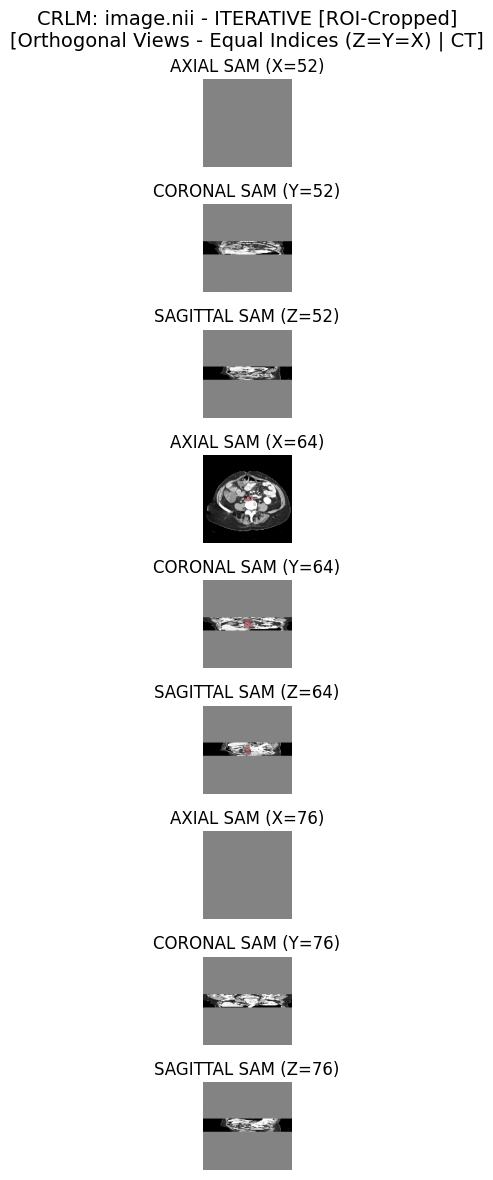

  📸 Plotting UNPROMPTED segmentation [Modality: CT]...

📊 Orthogonal Views: CRLM: image.nii - UNPROMPTED [ROI-Cropped]
Volume shape: (D=128, H=128, W=128)
Display window: [-149.71, 138.72]
Selected 3D points (Z=Y=X): [(52, 52, 52), (64, 64, 64), (76, 76, 76)]


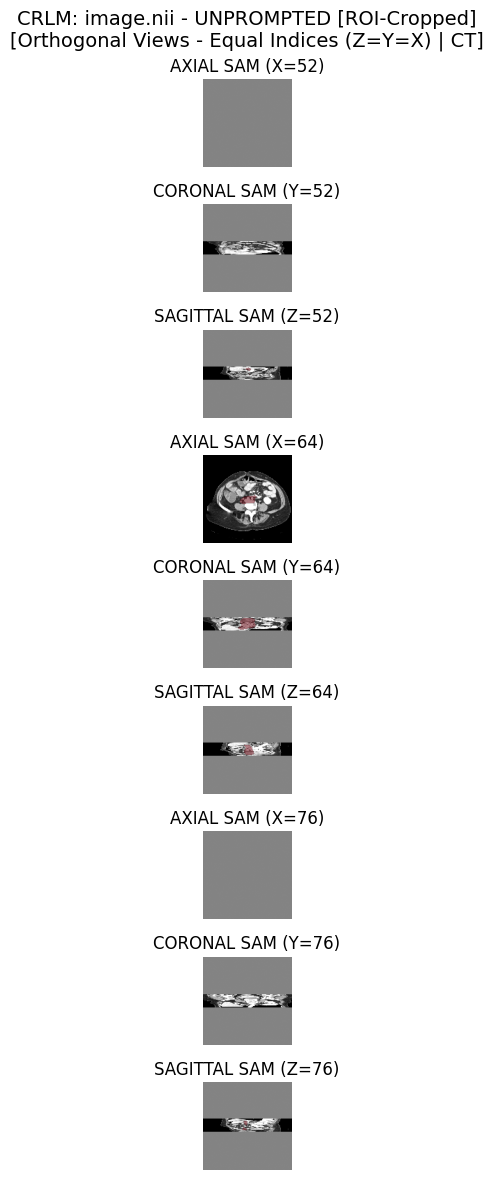


Processing dataset: DESMOID [ROI-Cropped]
Found 203 images

🔍 Visualizing and computing dice for 2 sample(s)

Processing: image.nii.gz
  Loading with ROI cropping (ROI-Cropped)...
    ROI crop: (512, 512, 20) -> (80, 98, 20)
    ROI crop: (512, 512, 20) -> (80, 98, 20)
    SAM input shape: torch.Size([1, 1, 128, 128, 128])
    Display shape: (128, 128, 128)
    Mask shape: (128, 128, 128)
    Mask sum: 6279.0 voxels

  🎯 Generating PROMPTED SAM segmentation (iterative refinement with 11 clicks)...
    🔄 Iterative Refinement with 11 clicks
      Click 1/11: Dice = 0.0060
      Click 3/11: Dice = 0.0060
      Click 6/11: Dice = 0.0060
      Click 9/11: Dice = 0.0060
      Click 11/11: Dice = 0.0060
    ✅ Final Dice: 0.7607 | Voxels: 5810
    Prompted segmentation: 5810 voxels

  🎯 Generating UNPROMPTED SAM segmentation (center point only)...
    Using CENTER point (unprompted): (64, 64, 64)
    Unprompted segmentation stats: min=0.000, max=0.982, threshold=0.5, voxels=6281
    Unprompte

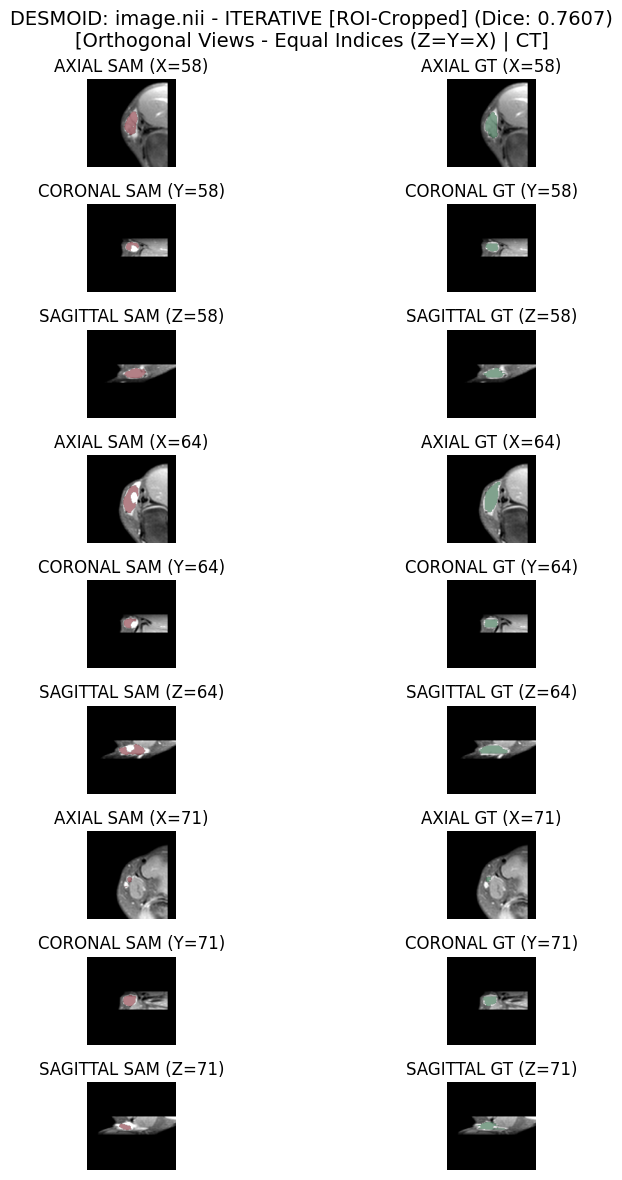

  📸 Plotting UNPROMPTED segmentation [Modality: CT]...

📊 Orthogonal Views: DESMOID: image.nii - UNPROMPTED [ROI-Cropped] (Dice: 0.8146)
Volume shape: (D=128, H=128, W=128)
Display window: [5814.72, 71998.14]
Selected 3D points (Z=Y=X): [(58, 58, 58), (64, 64, 64), (71, 71, 71)]


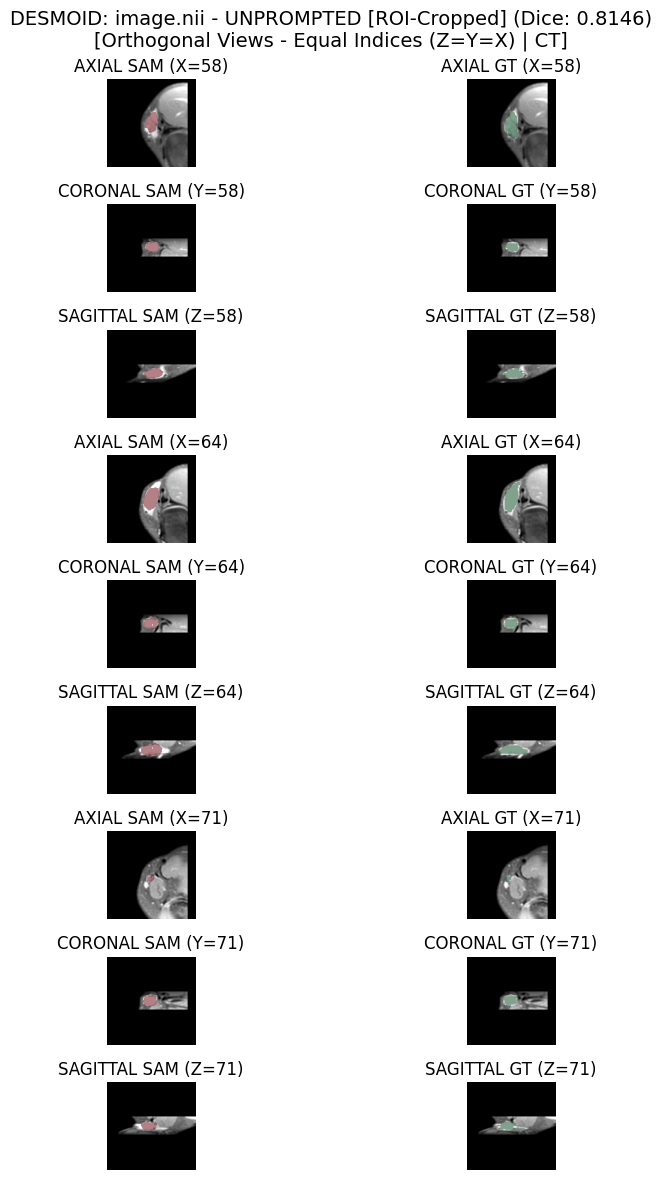


Processing: image.nii.gz
  Loading with ROI cropping (ROI-Cropped)...
    ROI crop: (560, 560, 40) -> (129, 133, 40)
    ROI crop: (560, 560, 40) -> (129, 133, 40)
    SAM input shape: torch.Size([1, 1, 128, 128, 128])
    Display shape: (128, 128, 128)
    Mask shape: (128, 128, 128)
    Mask sum: 34997.0 voxels

  🎯 Generating PROMPTED SAM segmentation (iterative refinement with 11 clicks)...
    🔄 Iterative Refinement with 11 clicks
      Click 1/11: Dice = 0.0328
      Click 3/11: Dice = 0.0328
      Click 6/11: Dice = 0.0328
      Click 9/11: Dice = 0.0328
      Click 11/11: Dice = 0.0328
    ✅ Final Dice: 0.4733 | Voxels: 47097
    Prompted segmentation: 47097 voxels

  🎯 Generating UNPROMPTED SAM segmentation (center point only)...
    Using CENTER point (unprompted): (64, 64, 64)
    Unprompted segmentation stats: min=0.000, max=0.999, threshold=0.5, voxels=54405
    Unprompted segmentation: 54405 voxels

  📊 DICE SCORES [ROI-Cropped]:
     Prompted (11-click iterative):   0.4

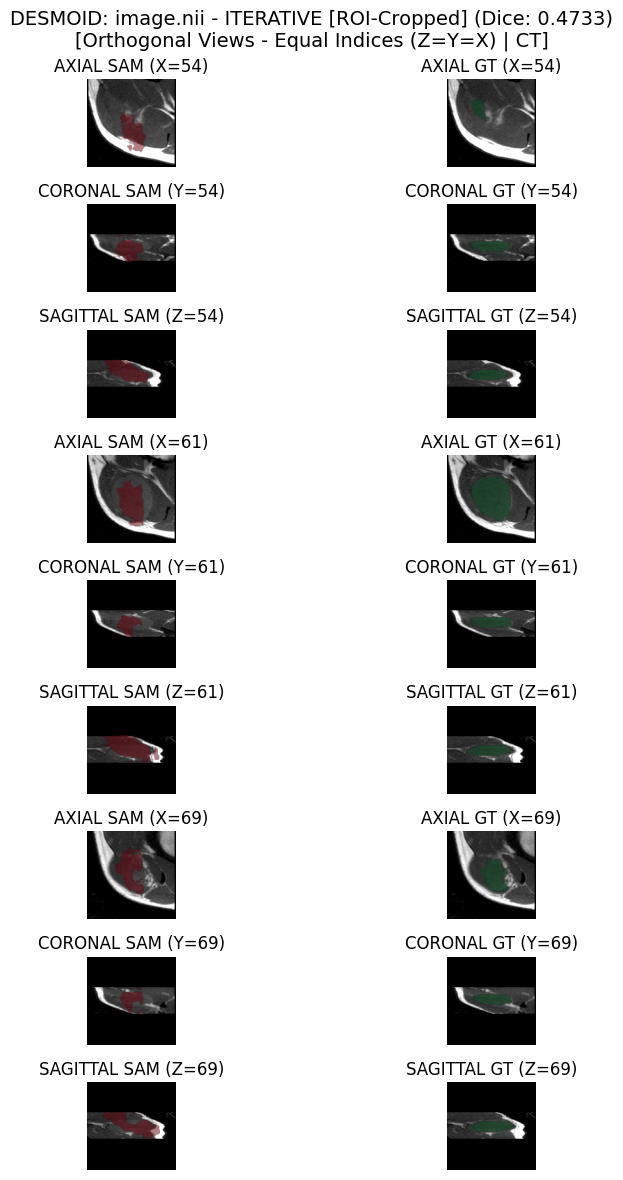

  📸 Plotting UNPROMPTED segmentation [Modality: CT]...

📊 Orthogonal Views: DESMOID: image.nii - UNPROMPTED [ROI-Cropped] (Dice: 0.5994)
Volume shape: (D=128, H=128, W=128)
Display window: [93701.27, 771150.81]
Selected 3D points (Z=Y=X): [(54, 54, 54), (61, 61, 61), (69, 69, 69)]


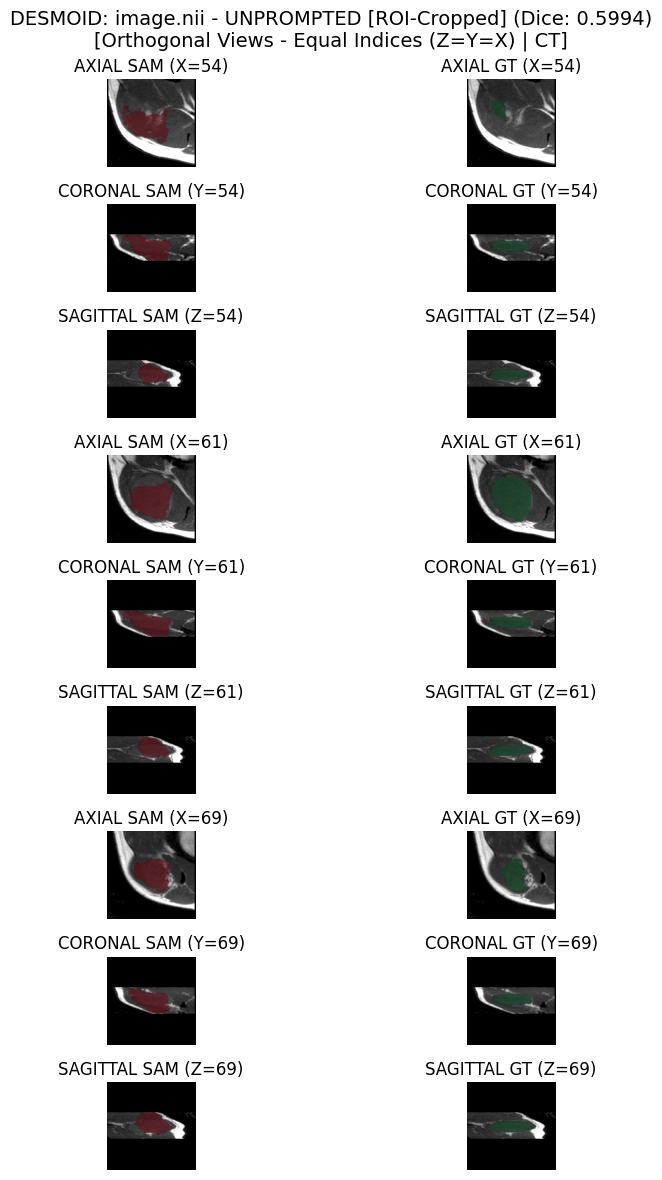


Processing dataset: GIST [ROI-Cropped]
Found 245 images

🔍 Visualizing and computing dice for 2 sample(s)

Processing: image.nii.gz
  Loading with ROI cropping (ROI-Cropped)...
    ROI crop: (512, 512, 161) -> (299, 289, 113)
    ROI crop: (512, 512, 161) -> (299, 289, 113)
    SAM input shape: torch.Size([1, 1, 128, 128, 128])
    Display shape: (128, 128, 128)
    Mask shape: (128, 128, 128)
    Mask sum: 113202.0 voxels

  🎯 Generating PROMPTED SAM segmentation (iterative refinement with 11 clicks)...
    🔄 Iterative Refinement with 11 clicks
      Click 1/11: Dice = 0.1024
      Click 3/11: Dice = 0.1024
      Click 6/11: Dice = 0.1024
      Click 9/11: Dice = 0.1024
      Click 11/11: Dice = 0.1024
    ✅ Final Dice: 0.6640 | Voxels: 84725
    Prompted segmentation: 84725 voxels

  🎯 Generating UNPROMPTED SAM segmentation (center point only)...
    Using CENTER point (unprompted): (64, 64, 64)
    Unprompted segmentation stats: min=0.000, max=1.000, threshold=0.5, voxels=116001
  

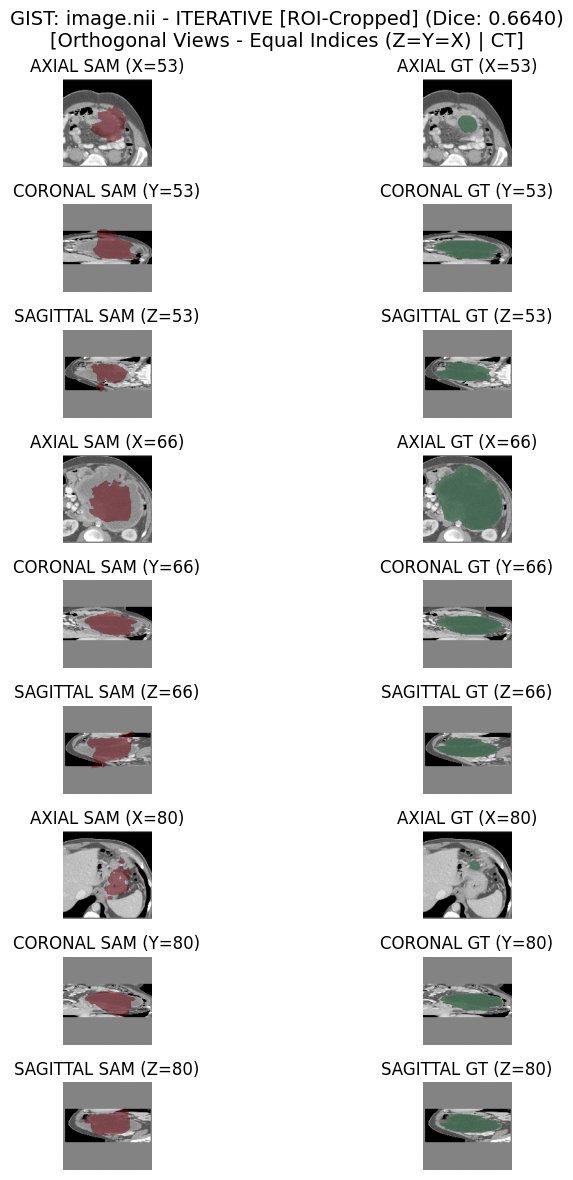

  📸 Plotting UNPROMPTED segmentation [Modality: CT]...

📊 Orthogonal Views: GIST: image.nii - UNPROMPTED [ROI-Cropped] (Dice: 0.8519)
Volume shape: (D=128, H=128, W=128)
Display window: [-261.92, 249.07]
Selected 3D points (Z=Y=X): [(53, 53, 53), (66, 66, 66), (80, 80, 80)]


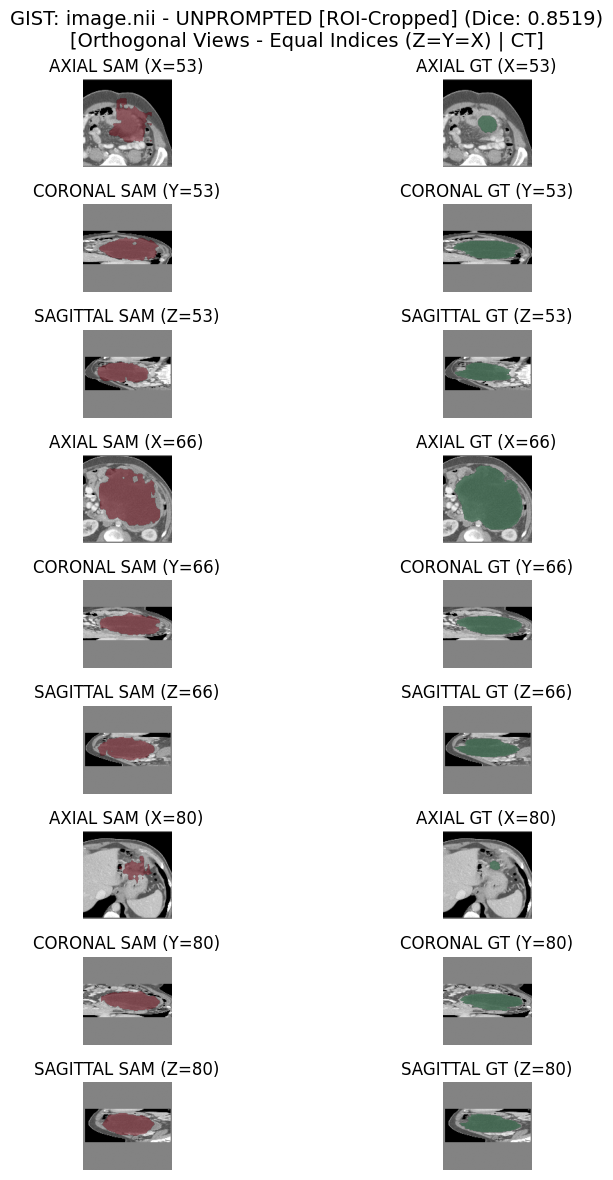


Processing: image.nii.gz
  Loading with ROI cropping (ROI-Cropped)...
    ROI crop: (512, 512, 157) -> (150, 156, 87)
    ROI crop: (512, 512, 157) -> (150, 156, 87)
    SAM input shape: torch.Size([1, 1, 128, 128, 128])
    Display shape: (128, 128, 128)
    Mask shape: (128, 128, 128)
    Mask sum: 61604.0 voxels

  🎯 Generating PROMPTED SAM segmentation (iterative refinement with 11 clicks)...
    🔄 Iterative Refinement with 11 clicks
      Click 1/11: Dice = 0.0571
      Click 3/11: Dice = 0.0571
      Click 6/11: Dice = 0.0571
      Click 9/11: Dice = 0.0571
      Click 11/11: Dice = 0.0571
    ✅ Final Dice: 0.8492 | Voxels: 52816
    Prompted segmentation: 52816 voxels

  🎯 Generating UNPROMPTED SAM segmentation (center point only)...
    Using CENTER point (unprompted): (64, 64, 64)
    Unprompted segmentation stats: min=0.000, max=1.000, threshold=0.5, voxels=53374
    Unprompted segmentation: 53374 voxels

  📊 DICE SCORES [ROI-Cropped]:
     Prompted (11-click iterative):   0

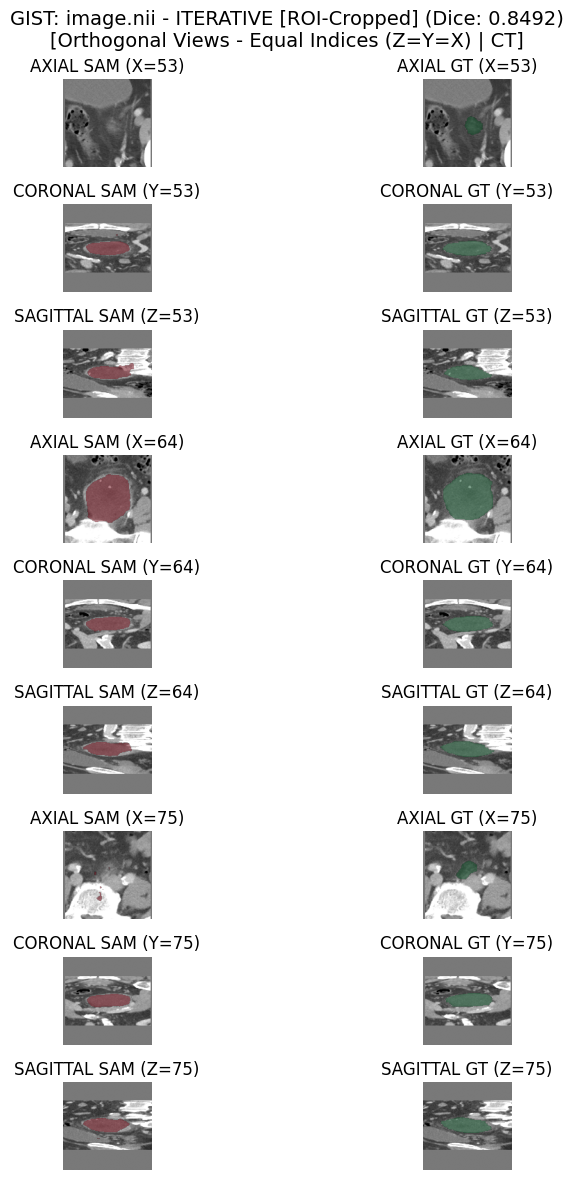

  📸 Plotting UNPROMPTED segmentation [Modality: CT]...

📊 Orthogonal Views: GIST: image.nii - UNPROMPTED [ROI-Cropped] (Dice: 0.8803)
Volume shape: (D=128, H=128, W=128)
Display window: [-209.84, 232.39]
Selected 3D points (Z=Y=X): [(53, 53, 53), (64, 64, 64), (75, 75, 75)]


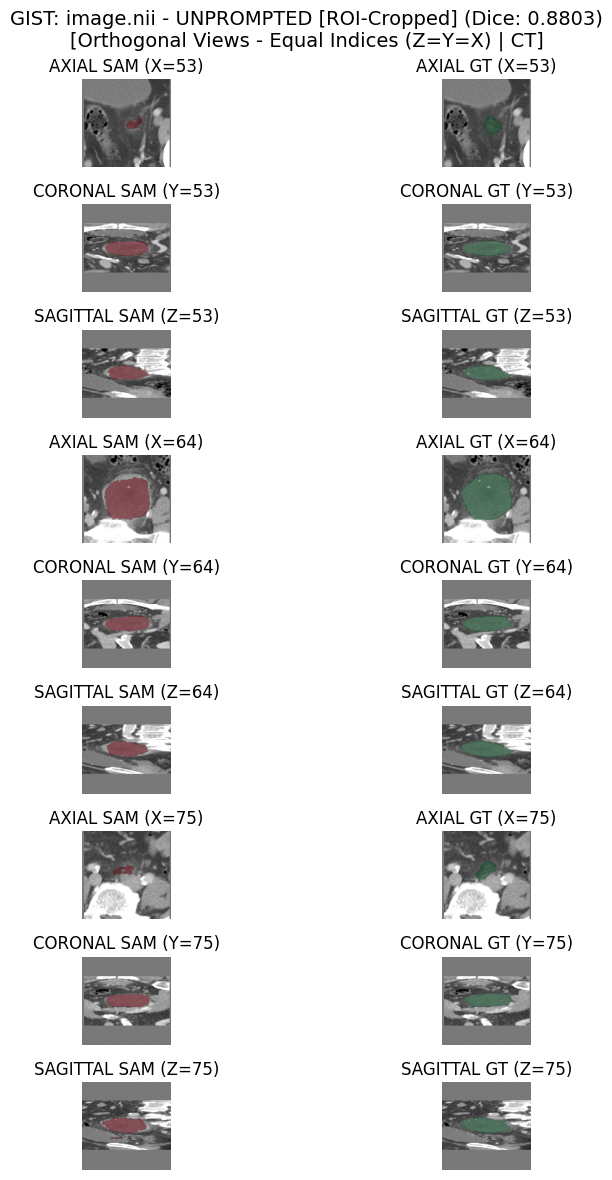


Processing dataset: LIPO [ROI-Cropped]
Found 115 images

🔍 Visualizing and computing dice for 2 sample(s)

Processing: image.nii.gz
  Loading with ROI cropping (ROI-Cropped)...
    ROI crop: (256, 224, 33) -> (165, 131, 33)
    ROI crop: (256, 224, 33) -> (165, 131, 33)
    SAM input shape: torch.Size([1, 1, 128, 128, 128])
    Display shape: (128, 128, 128)
    Mask shape: (128, 128, 128)
    Mask sum: 22565.0 voxels

  🎯 Generating PROMPTED SAM segmentation (iterative refinement with 11 clicks)...
    🔄 Iterative Refinement with 11 clicks
      Click 1/11: Dice = 0.0213
      Click 3/11: Dice = 0.0213
      Click 6/11: Dice = 0.0213
      Click 9/11: Dice = 0.0213
      Click 11/11: Dice = 0.0213
    ✅ Final Dice: 0.0382 | Voxels: 3314
    Prompted segmentation: 3314 voxels

  🎯 Generating UNPROMPTED SAM segmentation (center point only)...
    Using CENTER point (unprompted): (64, 64, 64)
    Unprompted segmentation stats: min=0.000, max=0.994, threshold=0.5, voxels=4391
    Unpromp

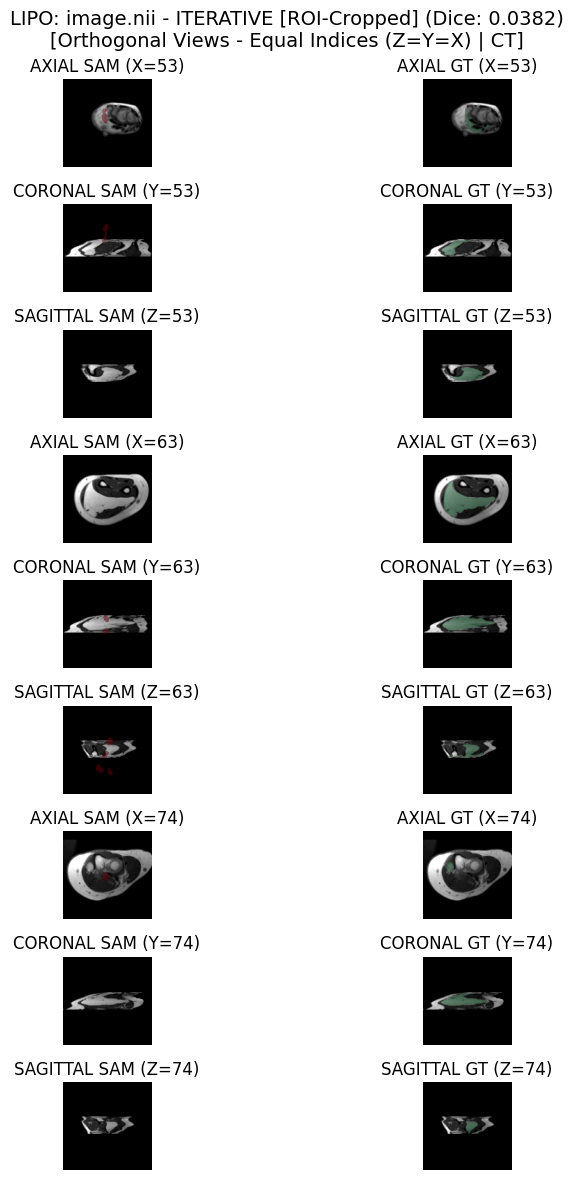

  📸 Plotting UNPROMPTED segmentation [Modality: CT]...

📊 Orthogonal Views: LIPO: image.nii - UNPROMPTED [ROI-Cropped] (Dice: 0.3055)
Volume shape: (D=128, H=128, W=128)
Display window: [106.72, 1471.84]
Selected 3D points (Z=Y=X): [(53, 53, 53), (63, 63, 63), (74, 74, 74)]


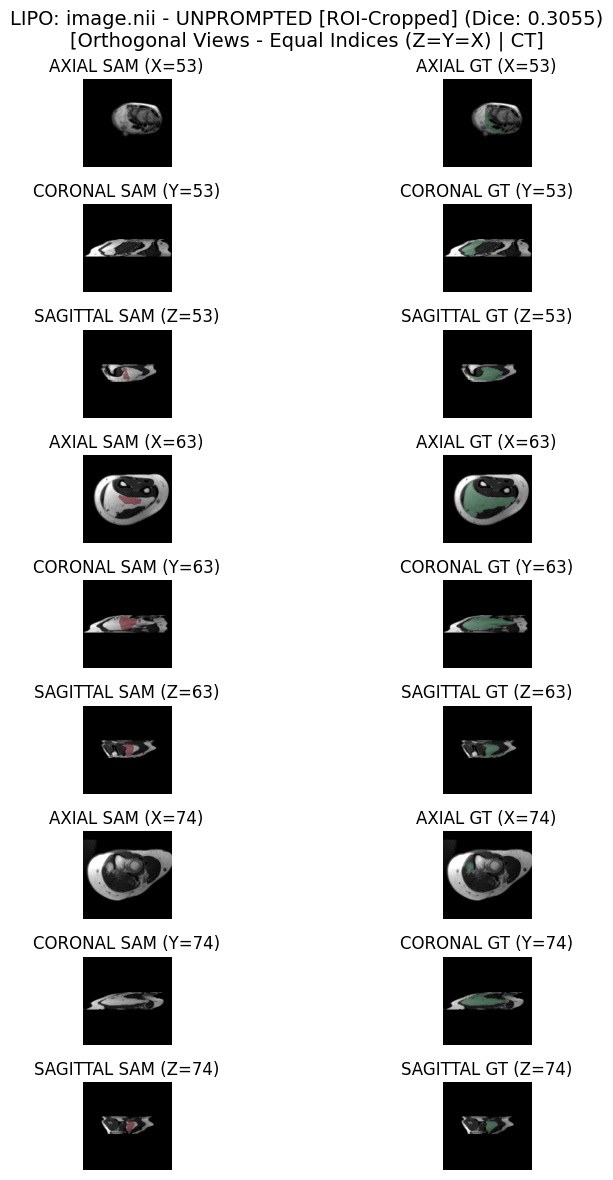


Processing: image.nii.gz
  Loading with ROI cropping (ROI-Cropped)...
    ROI crop: (512, 512, 47) -> (415, 363, 47)
    ROI crop: (512, 512, 47) -> (415, 363, 47)
    SAM input shape: torch.Size([1, 1, 128, 128, 128])
    Display shape: (128, 128, 128)
    Mask shape: (128, 128, 128)
    Mask sum: 9603.0 voxels

  🎯 Generating PROMPTED SAM segmentation (iterative refinement with 11 clicks)...
    🔄 Iterative Refinement with 11 clicks
      Click 1/11: Dice = 0.0091
      Click 3/11: Dice = 0.0091
      Click 6/11: Dice = 0.0091
      Click 9/11: Dice = 0.0091
      Click 11/11: Dice = 0.0091
    ✅ Final Dice: 0.0000 | Voxels: 2247
    Prompted segmentation: 2247 voxels

  🎯 Generating UNPROMPTED SAM segmentation (center point only)...
    Using CENTER point (unprompted): (64, 64, 64)
    Unprompted segmentation stats: min=0.000, max=0.995, threshold=0.5, voxels=1028
    Unprompted segmentation: 1028 voxels

  📊 DICE SCORES [ROI-Cropped]:
     Prompted (11-click iterative):   0.0000
 

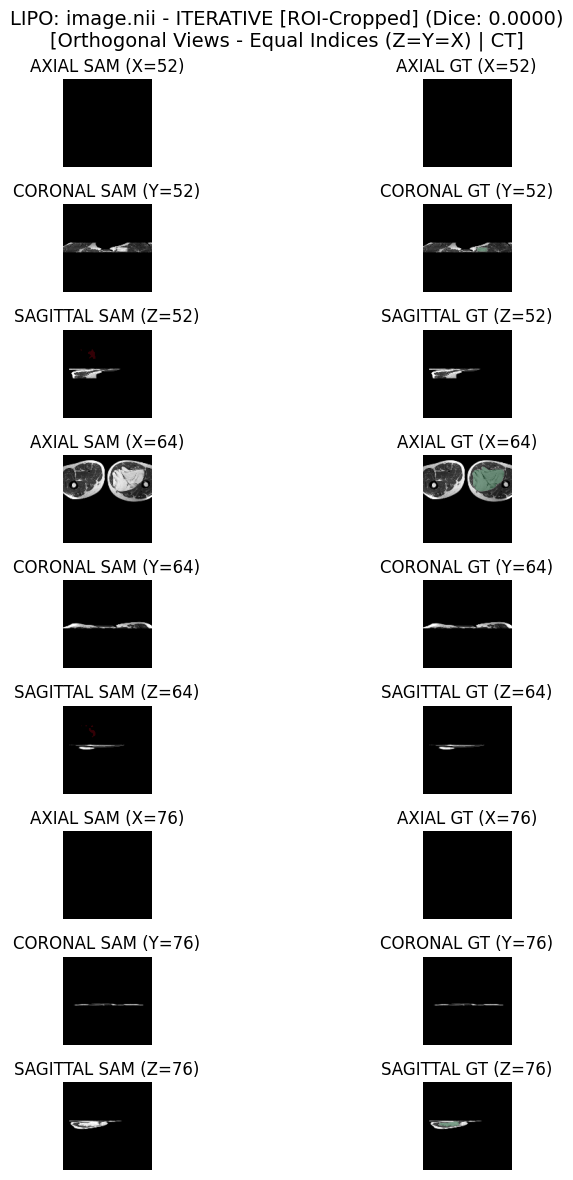

  📸 Plotting UNPROMPTED segmentation [Modality: CT]...

📊 Orthogonal Views: LIPO: image.nii - UNPROMPTED [ROI-Cropped] (Dice: 0.0000)
Volume shape: (D=128, H=128, W=128)
Display window: [79.03, 840.05]
Selected 3D points (Z=Y=X): [(52, 52, 52), (64, 64, 64), (76, 76, 76)]


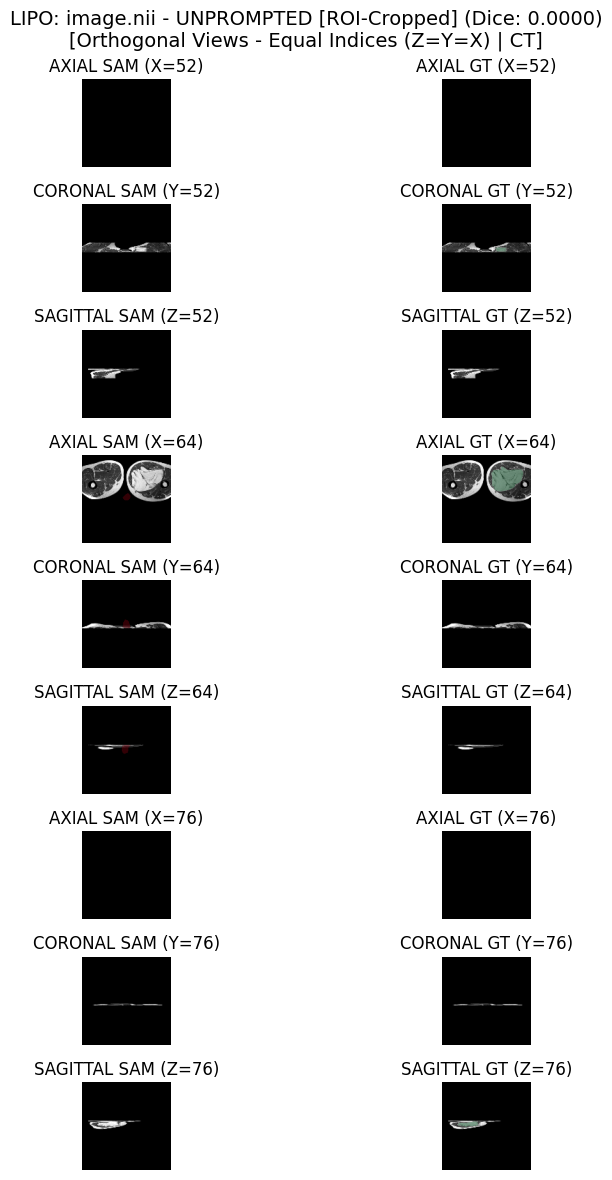


Processing dataset: LIVER [ROI-Cropped]
Found 186 images

🔍 Visualizing and computing dice for 2 sample(s)

Processing: image.nii.gz
  Loading with ROI cropping (ROI-Cropped)...
    ROI crop: (512, 512, 25) -> (157, 158, 25)
    ROI crop: (512, 512, 25) -> (157, 158, 25)
    SAM input shape: torch.Size([1, 1, 128, 128, 128])
    Display shape: (128, 128, 128)
    Mask shape: (128, 128, 128)
    Mask sum: 19374.0 voxels

  🎯 Generating PROMPTED SAM segmentation (iterative refinement with 11 clicks)...
    🔄 Iterative Refinement with 11 clicks
      Click 1/11: Dice = 0.0183
      Click 3/11: Dice = 0.0183
      Click 6/11: Dice = 0.0183
      Click 9/11: Dice = 0.0183
      Click 11/11: Dice = 0.0183
    ✅ Final Dice: 0.1927 | Voxels: 3111
    Prompted segmentation: 3111 voxels

  🎯 Generating UNPROMPTED SAM segmentation (center point only)...
    Using CENTER point (unprompted): (64, 64, 64)
    Unprompted segmentation stats: min=0.000, max=0.999, threshold=0.5, voxels=9557
    Unprom

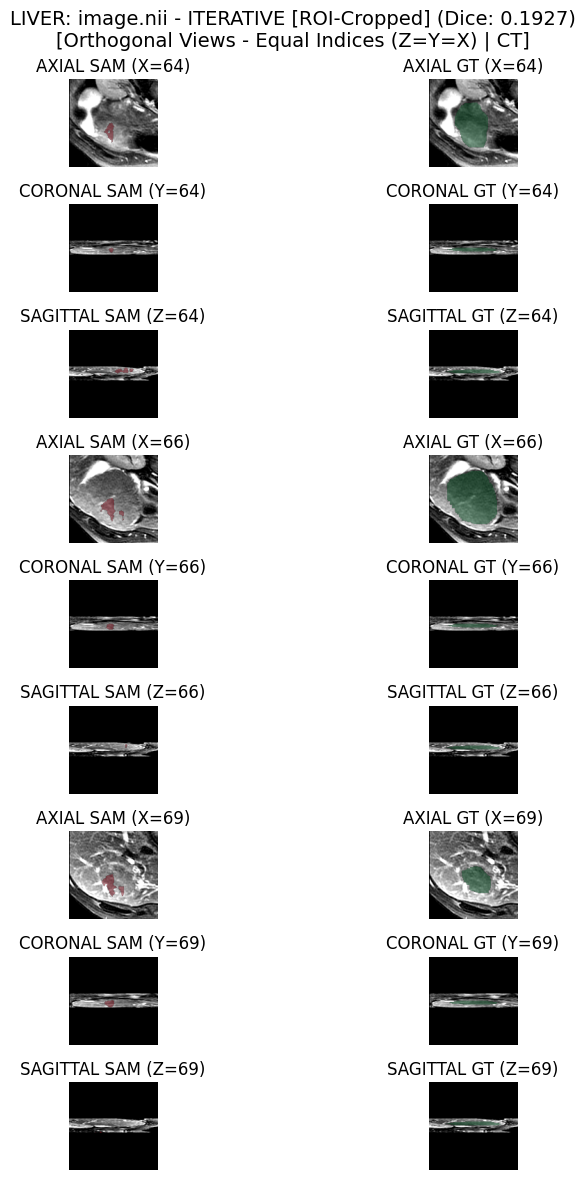

  📸 Plotting UNPROMPTED segmentation [Modality: CT]...

📊 Orthogonal Views: LIVER: image.nii - UNPROMPTED [ROI-Cropped] (Dice: 0.3638)
Volume shape: (D=128, H=128, W=128)
Display window: [120.86, 762.37]
Selected 3D points (Z=Y=X): [(64, 64, 64), (66, 66, 66), (69, 69, 69)]


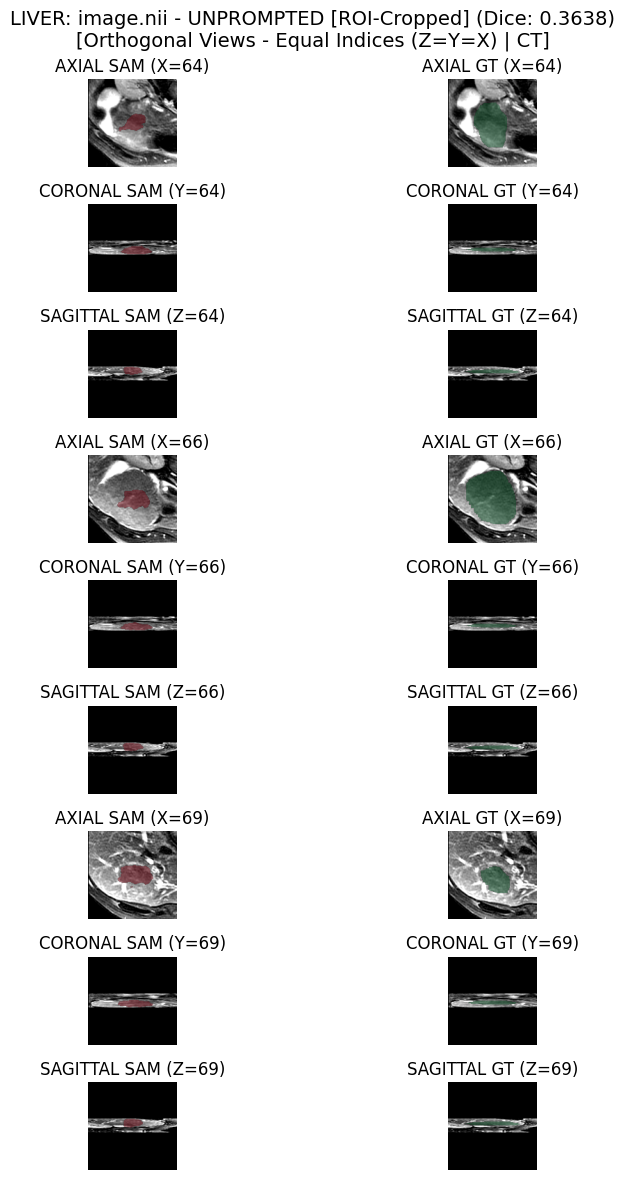


Processing: image.nii.gz
  Loading with ROI cropping (ROI-Cropped)...
    ROI crop: (512, 512, 30) -> (105, 103, 30)
    ROI crop: (512, 512, 30) -> (105, 103, 30)
    SAM input shape: torch.Size([1, 1, 128, 128, 128])
    Display shape: (128, 128, 128)
    Mask shape: (128, 128, 128)
    Mask sum: 9719.0 voxels

  🎯 Generating PROMPTED SAM segmentation (iterative refinement with 11 clicks)...
    🔄 Iterative Refinement with 11 clicks
      Click 1/11: Dice = 0.0092
      Click 3/11: Dice = 0.0092
      Click 6/11: Dice = 0.0092
      Click 9/11: Dice = 0.0092
      Click 11/11: Dice = 0.0092
    ✅ Final Dice: 0.2331 | Voxels: 2823
    Prompted segmentation: 2823 voxels

  🎯 Generating UNPROMPTED SAM segmentation (center point only)...
    Using CENTER point (unprompted): (64, 64, 64)
    Unprompted segmentation stats: min=0.000, max=0.995, threshold=0.5, voxels=4329
    Unprompted segmentation: 4329 voxels

  📊 DICE SCORES [ROI-Cropped]:
     Prompted (11-click iterative):   0.2331
 

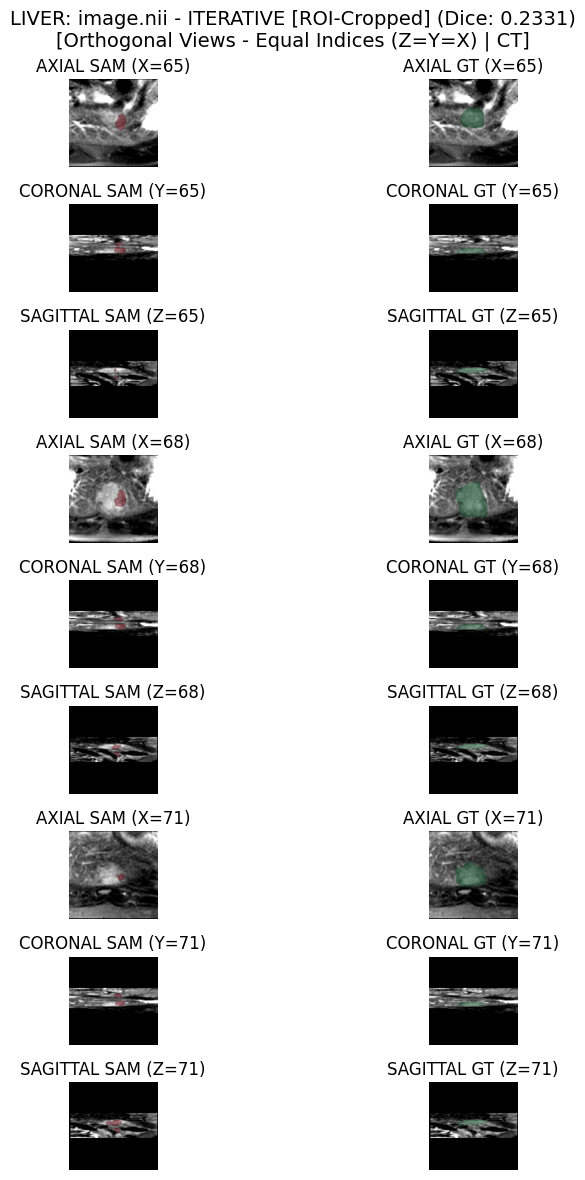

  📸 Plotting UNPROMPTED segmentation [Modality: CT]...

📊 Orthogonal Views: LIVER: image.nii - UNPROMPTED [ROI-Cropped] (Dice: 0.3890)
Volume shape: (D=128, H=128, W=128)
Display window: [23.64, 128.07]
Selected 3D points (Z=Y=X): [(65, 65, 65), (68, 68, 68), (71, 71, 71)]


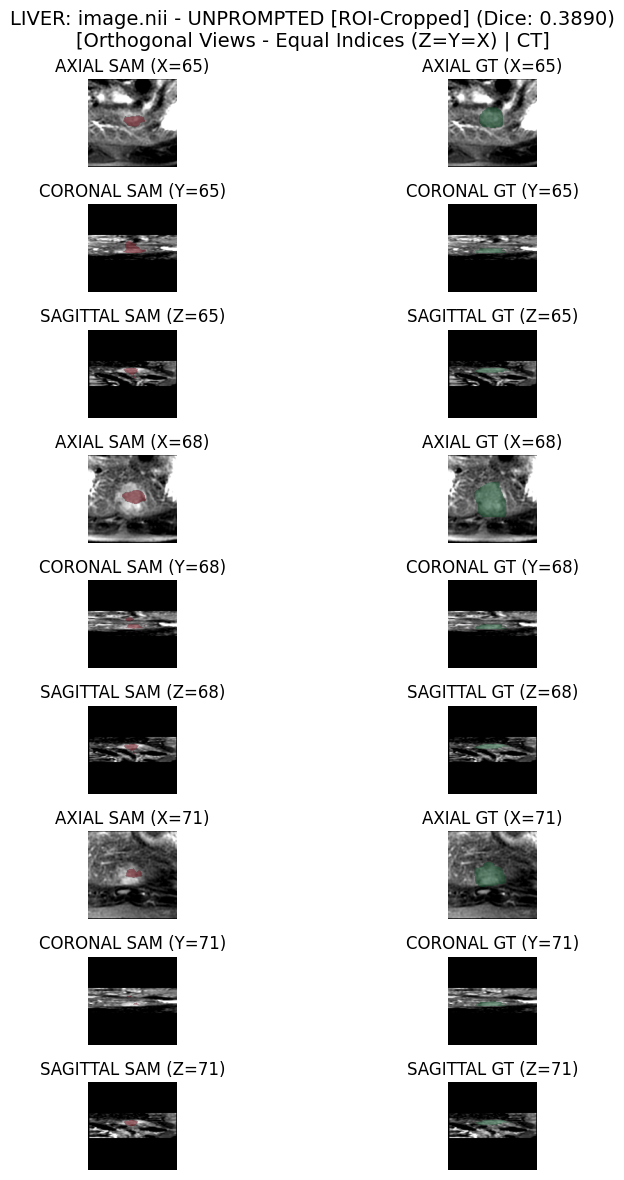


Processing dataset: MELANOMA [ROI-Cropped]
Found 103 images

🔍 Visualizing and computing dice for 2 sample(s)

Processing: image.nii.gz
  Loading image for SAM (WITH normalization)...
  Loading image for display (NO normalization)...
  Loading ground truth mask...
    SAM input shape: torch.Size([1, 1, 128, 128, 128])
    Display shape: (128, 128, 128)

  🎯 Generating PROMPTED SAM segmentation (iterative refinement with 11 clicks)...
    🔄 Iterative Refinement with 11 clicks
      Click 1/11: Dice = 0.0000
      Click 3/11: Dice = 0.0000
      Click 6/11: Dice = 0.0000
      Click 9/11: Dice = 0.0000
      Click 11/11: Dice = 0.0000
    ✅ Final Dice: 0.0000 | Voxels: 1356
    Prompted segmentation: 1356 voxels

  🎯 Generating UNPROMPTED SAM segmentation (center point only)...
    Using CENTER point (unprompted): (64, 64, 64)
    Unprompted segmentation stats: min=0.000, max=0.985, threshold=0.5, voxels=2395
    Unprompted segmentation: 2395 voxels

  📸 Plotting PROMPTED segmentation [

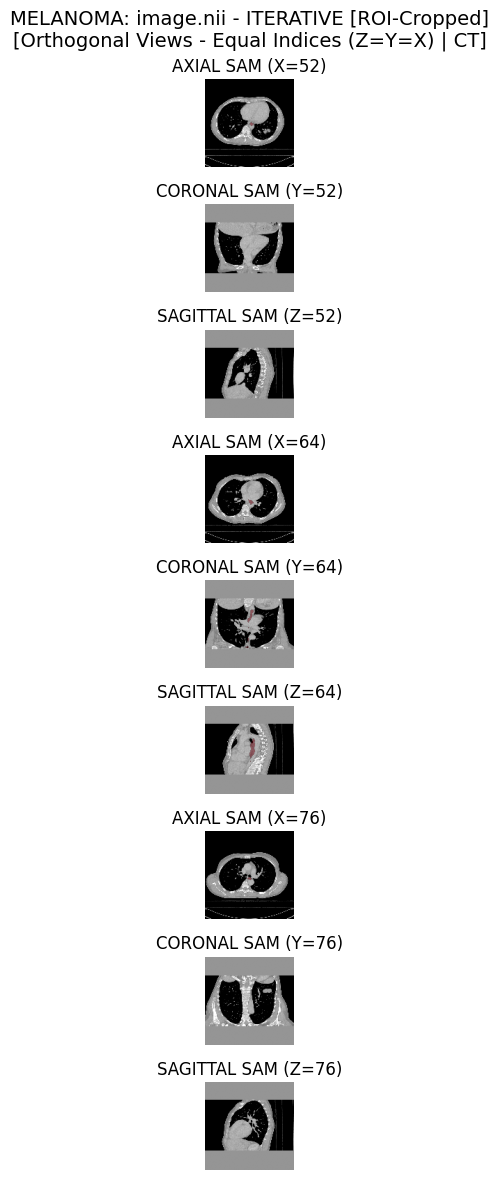

  📸 Plotting UNPROMPTED segmentation [Modality: CT]...

📊 Orthogonal Views: MELANOMA: image.nii - UNPROMPTED [ROI-Cropped]
Volume shape: (D=128, H=128, W=128)
Display window: [-683.12, 486.81]
Selected 3D points (Z=Y=X): [(52, 52, 52), (64, 64, 64), (76, 76, 76)]


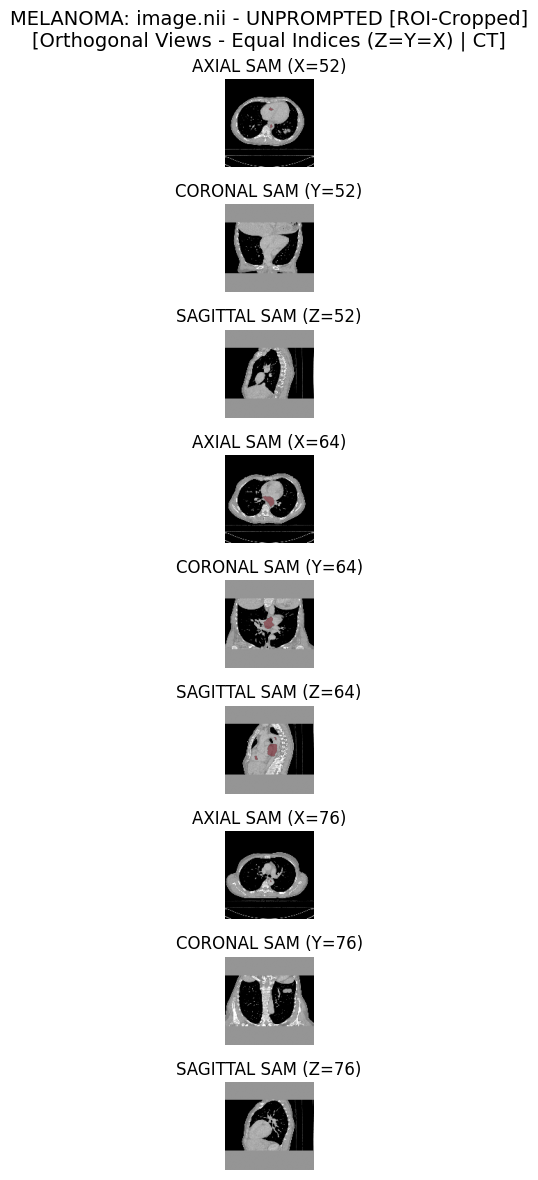


Processing: image.nii.gz
  Loading image for SAM (WITH normalization)...
  Loading image for display (NO normalization)...
  Loading ground truth mask...
    SAM input shape: torch.Size([1, 1, 128, 128, 128])
    Display shape: (128, 128, 128)

  🎯 Generating PROMPTED SAM segmentation (iterative refinement with 11 clicks)...
    🔄 Iterative Refinement with 11 clicks
      Click 1/11: Dice = 0.0000
      Click 3/11: Dice = 0.0000
      Click 6/11: Dice = 0.0000
      Click 9/11: Dice = 0.0000
      Click 11/11: Dice = 0.0000
    ✅ Final Dice: 0.0000 | Voxels: 525
    Prompted segmentation: 525 voxels

  🎯 Generating UNPROMPTED SAM segmentation (center point only)...
    Using CENTER point (unprompted): (64, 64, 64)
    Unprompted segmentation stats: min=0.000, max=0.998, threshold=0.5, voxels=10695
    Unprompted segmentation: 10695 voxels

  📸 Plotting PROMPTED segmentation [Modality: CT]...

📊 Orthogonal Views: MELANOMA: image.nii - ITERATIVE [ROI-Cropped]
Volume shape: (D=128, H=128

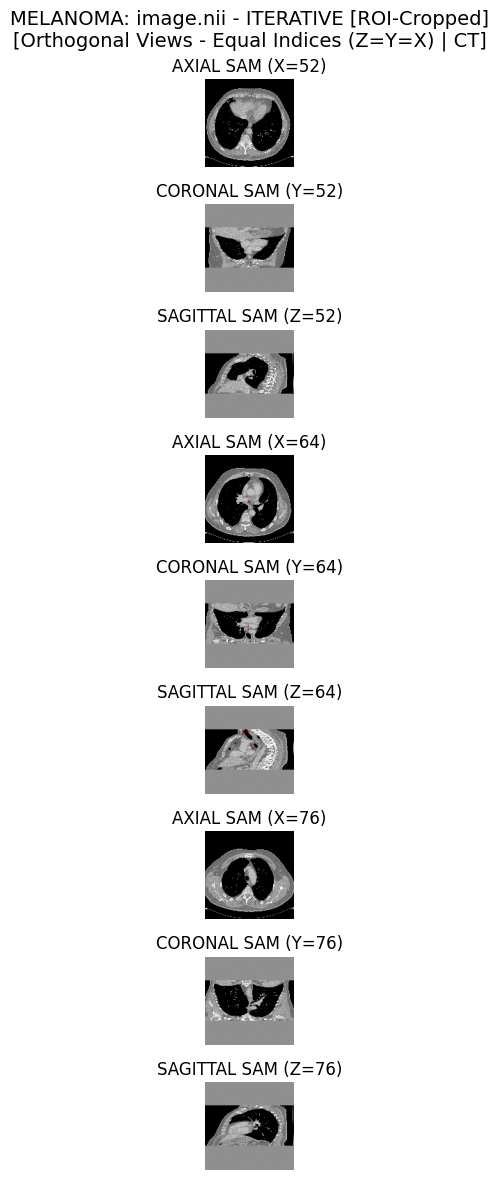

  📸 Plotting UNPROMPTED segmentation [Modality: CT]...

📊 Orthogonal Views: MELANOMA: image.nii - UNPROMPTED [ROI-Cropped]
Volume shape: (D=128, H=128, W=128)
Display window: [-467.91, 369.50]
Selected 3D points (Z=Y=X): [(52, 52, 52), (64, 64, 64), (76, 76, 76)]


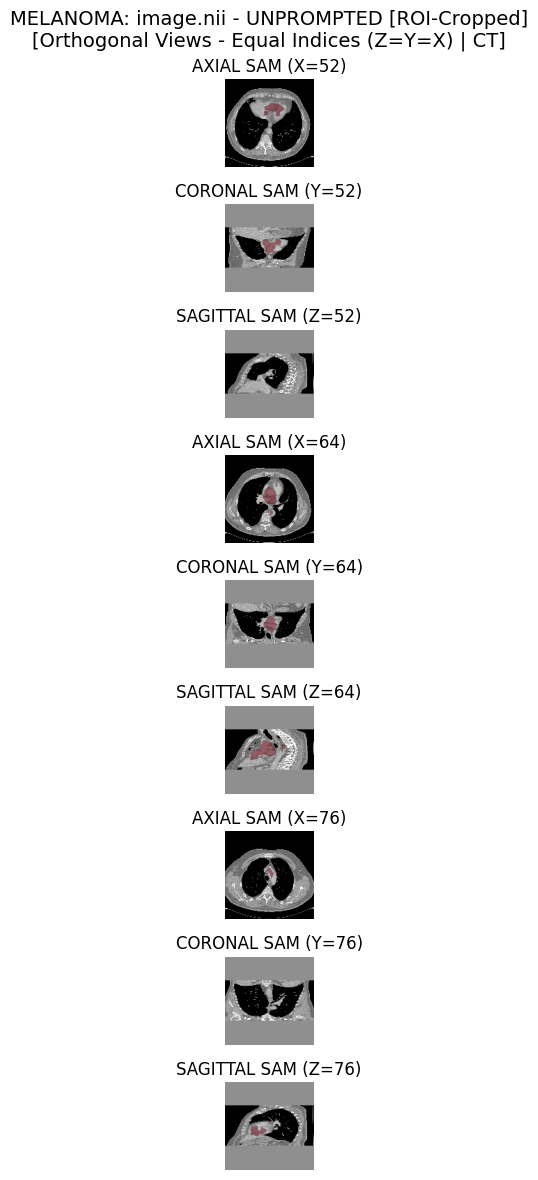


💾 Saved per-image Dice scores to: c:\Users\cahel\Desktop\Med3Tab-PFN\results\sam_visualization\dice_scores_per_image.csv
💾 Saved summary statistics to: c:\Users\cahel\Desktop\Med3Tab-PFN\results\sam_visualization\dice_scores_summary.csv


,dataset,image,preprocessing,dice_prompted,dice_unprompted,dice_improvement
0,desmoid,image.nii.gz,ResizeLargestTo,0.128174,0.067818,0.060356
1,desmoid,image.nii.gz,ResizeLargestTo,0.000000,0.000000,0.000000
2,gist,image.nii.gz,ResizeLargestTo,0.387095,0.005058,0.382037
3,gist,image.nii.gz,ResizeLargestTo,0.077736,0.221092,-0.143356
4,lipo,image.nii.gz,ResizeLargestTo,0.106536,0.238073,-0.131537
5,lipo,image.nii.gz,ResizeLargestTo,0.000000,0.009024,-0.009024
6,liver,image.nii.gz,ResizeLargestTo,0.000000,0.000000,0.000000
7,liver,image.nii.gz,ResizeLargestTo,0.179357,0.064848,0.114509
8,desmoid,image.nii.gz,ROI-Cropped,0.760692,0.814650,-0.053958
9,desmoid,image.nii.gz,ROI-Cropped,0.473335,0.599383,-0.126047


dice_prompted                         dice_unprompted  \
                                 mean     std     min     max            mean   
preprocessing   dataset                                                         
ROI-Cropped     desmoid        0.6170  0.2032  0.4733  0.7607          0.7070   
                gist           0.7566  0.1310  0.6640  0.8492          0.8661   
                lipo           0.0191  0.0270  0.0000  0.0382          0.1527   
                liver          0.2129  0.0286  0.1927  0.2331          0.3764   
ResizeLargestTo desmoid        0.0641  0.0906  0.0000  0.1282          0.0339   
                gist           0.2324  0.2187  0.0777  0.3871          0.1131   
                lipo           0.0533  0.0753  0.0000  0.1065          0.1235   
                liver          0.0897  0.1268  0.0000  0.1794          0.0324   

                                                dice_improvement          \
                            std     min     max             mean     std   
preprocessing   dataset                                                    
ROI-Cropped     desmoid  0.1522  0.5994  0.8146          -0.0900  0.0510   
                gist     0.0201  0.8519  0.8803          -0.1095  0.1109   
                lipo     0.2160  0.0000  0.3055          -0.1336  0.1890   
                liver    0.0178  0.3638  0.3890          -0.1635  0.0109   
ResizeLargestTo desmoid  0.0480  0.0000  0.0678           0.0302  0.0427   
                gist     0.1528  0.0051  0.2211           0.1193  0.3715   
                lipo     0.1620  0.0090  0.2381          -0.0703  0.0866   
                liver    0.0459  0.0000  0.0648           0.0573  0.0810   

                                         
                            min     max  
preprocessing   dataset                  
ROI-Cropped     desmoid -0.1260 -0.0540  
                gist    -0.1879 -0.0311  
                lipo    -0.2673  0.0000  
                liver   -0.1712 -0.1558  
ResizeLargestTo desmoid  0.0000  0.0604  
                gist    -0.1434  0.3820  
                lipo    -0.1315 -0.0090  
                liver    0.0000  0.1145

In [62]:
results = []
results_dir = project_root / "results" / "sam_visualization"
results_dir.mkdir(parents=True, exist_ok=True)

# ROI Cropping Helper Functions (inline)
def get_bounding_box(mask_array):
    """Get bounding box of non-zero region in 3D mask."""
    where = np.where(mask_array > 0)
    if len(where[0]) == 0:
        return None
    z_min, z_max = where[0].min(), where[0].max()
    y_min, y_max = where[1].min(), where[1].max()
    x_min, x_max = where[2].min(), where[2].max()
    return (z_min, z_max, y_min, y_max, x_min, x_max)

def add_margin_to_bbox(bbox, margin, shape):
    """Add margin to bounding box, respecting image boundaries."""
    z_min, z_max, y_min, y_max, x_min, x_max = bbox
    z_min = max(0, z_min - margin)
    z_max = min(shape[0] - 1, z_max + margin)
    y_min = max(0, y_min - margin)
    y_max = min(shape[1] - 1, y_max + margin)
    x_min = max(0, x_min - margin)
    x_max = min(shape[2] - 1, x_max + margin)
    return (z_min, z_max, y_min, y_max, x_min, x_max)

def crop_array_to_roi(array, bbox):
    """Crop array to ROI."""
    z_min, z_max, y_min, y_max, x_min, x_max = bbox
    return array[z_min:z_max+1, y_min:y_max+1, x_min:x_max+1]

def load_with_roi_crop(img_path, mask_path, img_size, roi_margin, for_sam=True):
    """Load image and mask with ROI cropping."""
    # Load raw arrays
    sitk_img = sitk.ReadImage(str(img_path))
    sitk_arr_img, _ = tio.data.io.sitk_to_nib(sitk_img)
    
    sitk_mask = sitk.ReadImage(str(mask_path))
    sitk_arr_mask, _ = tio.data.io.sitk_to_nib(sitk_mask)
    
    # Get numpy arrays
    img_np = sitk_arr_img.squeeze()
    mask_np = sitk_arr_mask.squeeze()
    
    # Get bounding box from mask
    bbox = get_bounding_box(mask_np)
    if bbox is None:
        print("    WARNING: Empty mask, falling back to full volume")
        bbox = (0, mask_np.shape[0]-1, 0, mask_np.shape[1]-1, 0, mask_np.shape[2]-1)
    
    # Add margin
    bbox = add_margin_to_bbox(bbox, roi_margin, mask_np.shape)
    
    # Crop to ROI
    img_cropped = crop_array_to_roi(img_np, bbox)
    mask_cropped = crop_array_to_roi(mask_np, bbox)
    
    print(f"    ROI crop: {img_np.shape} -> {img_cropped.shape}")
    
    # Create TorchIO subjects from cropped arrays
    img_tensor = torch.from_numpy(img_cropped).float().unsqueeze(0)
    mask_tensor = torch.from_numpy(mask_cropped).float().unsqueeze(0)
    
    subject_img = tio.Subject(image=tio.ScalarImage(tensor=img_tensor))
    subject_mask = tio.Subject(label=tio.LabelMap(tensor=mask_tensor))
    
    # Apply CT clamping if needed
    if "/ct_" in str(img_path).lower() or "_ct" in str(img_path).lower():
        subject_img = tio.Clamp(-1000, 1000)(subject_img)
    
    # Transform: Resize + Pad (+ Normalization for SAM)
    if for_sam:
        transform = tio.Compose([
            tio.ToCanonical(),
            ResizeLargestTo(target_size=img_size),
            tio.CropOrPad(target_shape=(img_size, img_size, img_size)),
            tio.ZNormalization(masking_method=_znorm_masking_method),
        ])
    else:
        transform = tio.Compose([
            tio.ToCanonical(),
            ResizeLargestTo(target_size=img_size),
            tio.CropOrPad(target_shape=(img_size, img_size, img_size)),
        ])
    
    mask_transform = tio.Compose([
        tio.ToCanonical(),
        ResizeLargestTo(target_size=img_size),
        tio.CropOrPad(target_shape=(img_size, img_size, img_size)),
    ])
    
    subject_img = transform(subject_img)
    subject_mask = mask_transform(subject_mask)
    
    if for_sam:
        image = subject_img.image.data.clone().detach().unsqueeze(0).float()  # (1, 1, D, H, W)
    else:
        image = subject_img.image.data.squeeze().numpy()
    
    mask = subject_mask.label.data.squeeze().numpy()
    mask = (mask > 0).astype(float)
    
    return image, mask

# Run experiments with BOTH preprocessing strategies
preprocessing_strategies = [
    {"name": "ResizeLargestTo", "use_roi_crop": False, "roi_margin": 0},
    {"name": "ROI-Cropped", "use_roi_crop": True, "roi_margin": ROI_MARGIN}
]

for strategy in preprocessing_strategies:
    preproc_name = strategy["name"]
    use_roi = strategy["use_roi_crop"]
    margin = strategy["roi_margin"]
    
    print("\n" + "="*80)
    print(f"🔬 PREPROCESSING STRATEGY: {preproc_name}")
    print("="*80)
    if use_roi:
        print(f"   • ROI-cropped with {margin}px margin")
        print(f"   • Tumor-centered volumes")
        print(f"   • Better for small lesions")
    else:
        print(f"   • Whole volume with ResizeLargestTo")
        print(f"   • Preserves anatomical context")
        print(f"   • Minimal data loss")
    print("="*80)
    
    for dataset_name, dataset_config in config['datasets'].items():
        print("\n" + "="*60)
        print(f"Processing dataset: {dataset_name.upper()} [{preproc_name}]")
        print("="*60)
        
        images, labels = find_dataset_images(dataset_config, sam3d_root, project_root)
        print(f"Found {len(images)} images")
        
        if len(images) == 0:
            print(f"  No images found for {dataset_name}")
            continue
        
        # Only process PLOT_SAMPLES_PER_DATASET images (visualize + compute dice)
        visual_count = min(PLOT_SAMPLES_PER_DATASET, len(images)) if PLOT_SAMPLES_PER_DATASET else 0
        visual_indices = list(range(visual_count))
        
        print(f"\n🔍 Visualizing and computing dice for {len(visual_indices)} sample(s)")
        
        for idx in visual_indices:
            img_path = images[idx]
            label_path = labels[idx] if idx < len(labels) else None
            
            print(f"\nProcessing: {img_path.name}")
            
            try:
                # Load data with current preprocessing strategy
                if use_roi and label_path:
                    print(f"  Loading with ROI cropping ({preproc_name})...")
                    image_tensor_sam, gt_mask = load_with_roi_crop(
                        img_path, label_path, img_size, margin, for_sam=True
                    )
                    image_vol_display, _ = load_with_roi_crop(
                        img_path, label_path, img_size, margin, for_sam=False
                    )
                else:
                    print(f"  Loading image for SAM (WITH normalization)...")
                    image_tensor_sam = load_volume_for_sam(img_path, img_size=img_size)
                    
                    print(f"  Loading image for display (NO normalization)...")
                    image_vol_display = load_volume_for_display(img_path, img_size=img_size)
                    
                    print(f"  Loading ground truth mask...")
                    gt_mask = load_mask_for_sam(label_path, img_size=img_size) if label_path else None
                
                print(f"    SAM input shape: {image_tensor_sam.shape}")
                print(f"    Display shape: {image_vol_display.shape}")
                if gt_mask is not None:
                    print(f"    Mask shape: {gt_mask.shape}")
                    print(f"    Mask sum: {gt_mask.sum()} voxels")
                
                # Generate PROMPTED segmentation (now with iterative refinement!)
                print(f"\n  🎯 Generating PROMPTED SAM segmentation (iterative refinement with {NUM_CLICKS} clicks)...")
                if gt_mask is not None:
                    seg_prompted = generate_sam_with_bbox_prompt(
                        model, image_tensor_sam, gt_mask, device
                    )
                else:
                    seg_prompted = generate_sam_with_bbox_prompt(
                        model, image_tensor_sam, np.zeros_like(image_vol_display), device
                    )
                print(f"    Prompted segmentation: {seg_prompted.sum()} voxels")
                
                # Generate UNPROMPTED segmentation
                print(f"\n  🎯 Generating UNPROMPTED SAM segmentation (center point only)...")
                seg_unprompted = generate_sam_unprompted(
                    model, image_tensor_sam, device,
                    threshold=SEGMENTATION_THRESHOLD
                )
                print(f"    Unprompted segmentation: {seg_unprompted.sum()} voxels")
                
                # Compute Dice scores
                dice_prompted = None
                dice_unprompted = None
                if gt_mask is not None:
                    dice_prompted = compute_dice_score(seg_prompted, gt_mask)
                    dice_unprompted = compute_dice_score(seg_unprompted, gt_mask)
                    improvement = dice_prompted - dice_unprompted
                    
                    print(f"\n  📊 DICE SCORES [{preproc_name}]:")
                    print(f"     Prompted (11-click iterative):   {dice_prompted:.4f}")
                    print(f"     Unprompted (center only): {dice_unprompted:.4f}")
                    print(f"     Improvement: {improvement:+.4f}")
                    
                    results.append({
                        "dataset": dataset_name,
                        "image": img_path.name,
                        "preprocessing": preproc_name,
                        "dice_prompted": float(dice_prompted),
                        "dice_unprompted": float(dice_unprompted),
                        "dice_improvement": float(improvement)
                    })
                    
                # Detect modality from filename
                modality = "MR" if "_MR" in img_path.name or "Lipo" in img_path.name else "CT"
                
                # Plot PROMPTED segmentation
                print(f"\n  📸 Plotting PROMPTED segmentation [Modality: {modality}]...")
                title_prompted = f"{dataset_name.upper()}: {img_path.stem} - ITERATIVE [{preproc_name}]"
                if dice_prompted is not None:
                    title_prompted += f" (Dice: {dice_prompted:.4f})"
                
                fig = plot_orthogonal_views(
                    image_vol_display,
                    seg_prompted,
                    gt_mask,
                    title=title_prompted,
                    n_slices=3,
                    modality=modality
                )
                plt.show()
                
                # Plot UNPROMPTED segmentation
                print(f"  📸 Plotting UNPROMPTED segmentation [Modality: {modality}]...")
                title_unprompted = f"{dataset_name.upper()}: {img_path.stem} - UNPROMPTED [{preproc_name}]"
                if dice_unprompted is not None:
                    title_unprompted += f" (Dice: {dice_unprompted:.4f})"
                
                fig = plot_orthogonal_views(
                    image_vol_display,
                    seg_unprompted,
                    gt_mask,
                    title=title_unprompted,
                    n_slices=3,
                    modality=modality
                )
                plt.show()
                
            except Exception as e:
                print(f"  ❌ Error processing {img_path.name}: {e}")
                import traceback
                traceback.print_exc()
                continue

# Save results
if results:
    df = pd.DataFrame(results)
    
    # Per-image results
    per_image_path = results_dir / "dice_scores_per_image.csv"
    df.to_csv(per_image_path, index=False)
    print(f"\n💾 Saved per-image Dice scores to: {per_image_path}")
    
    # Summary statistics by preprocessing method
    summary = df.groupby(['preprocessing', 'dataset']).agg({
        'dice_prompted': ['mean', 'std', 'min', 'max'],
        'dice_unprompted': ['mean', 'std', 'min', 'max'],
        'dice_improvement': ['mean', 'std', 'min', 'max']
    }).round(4)
    
    summary_path = results_dir / "dice_scores_summary.csv"
    summary.to_csv(summary_path)
    print(f"💾 Saved summary statistics to: {summary_path}")
    
    display(df)
    display(summary)


## Summary

This notebook visualizes **2 images per dataset** (configurable via `PLOT_SAMPLES_PER_DATASET`).

For each visualized image, it:
1. Generates **PROMPTED** segmentation (with 11-click iterative refinement)
2. Generates **UNPROMPTED** segmentation (center point only)
3. Computes Dice scores for both approaches
4. Shows orthogonal views (Axial, Coronal, Sagittal) for both

**Note:** Dice scores are computed ONLY for the visualized images, not for all images in the dataset.

Results are saved to `results/sam_visualization/dice_scores_per_image.csv` and `dice_scores_summary.csv`.